In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
for f in os.listdir(CSD_DIR):
    print(f)

Mounted at /content/drive
CMU_MOSEI_COVAREP.csd
CMU_MOSEI_TimestampedWords.csd
CMU_MOSEI_TimestampedWords.csd.4
CMU_MOSEI_TimestampedWords.csd.3
CMU_MOSEI_TimestampedWords.csd.1
CMU_MOSEI_VisualFacet42.csd
CMU_MOSEI_Labels.csd
CMU_MOSEI_Labels.csd.5
CMU_MOSEI_Labels.csd.4
CMU_MOSEI_Labels.csd.1
CMU_MOSEI_COVAREP.csd.1
CMU_MOSEI_VisualFacet42.csd.1
CMU_MOSEI_COVAREP.csd.2
CMU_MOSEI_TimestampedWords.csd.2
CMU_MOSEI_Labels.csd.2
CMU_MOSEI_COVAREP.csd.3
CMU_MOSEI_VisualFacet42.csd.2
CMU_MOSEI_Labels.csd.3
CMU_MOSEI_COVAREP.csd.4
CMU_MOSEI_VisualFacet42.csd.3
CMU_MOSEI_COVAREP.csd.5
CMU_MOSEI_VisualFacet42.csd.4
CMU_MOSEI_TimestampedWords.csd.5
label.csv
bert_embeddings.pkl
noise_robustness_v4.png
best_model.pt
training_curves.png
best_adaptive.pt
best_baseline.pt
comparison.png
adaptive_detail.png
noise_robustness.png
final_adaptive.pt
final_baseline.pt
best_adaptive_v4.pt
best_baseline_v4.pt
adaptive_detail_v4.png
comparison_v4.png
adaptive_detail_v5.png
comparison_v5.png
noise_robustness

In [ ]:
import pickle
import json
import os
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

# ── Load your data ────────────────────────────────────────────────────────────
CSD_DIR    = '/content/drive/MyDrive/CMU_MOSEI/'
BERT_CACHE = CSD_DIR + 'bert_embeddings_full.pkl'
ALIGNED    = CSD_DIR + 'mosei_full_aligned.pkl'

with open(ALIGNED, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

# ── Output structure ──────────────────────────────────────────────────────────
DATA_ROOT  = Path('mmai-data')
IMAGE_DIR  = DATA_ROOT / 'images'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def label_to_sentiment(label):
    if label > 0.5:
        return 'positive'
    elif label < -0.5:
        return 'negative'
    else:
        return 'neutral'

def make_sentiment_image(sid, bert_vec, label, out_path):
    fig, ax = plt.subplots(figsize=(4, 2))
    vec = np.array(bert_vec[:128]).reshape(8, 16)
    ax.imshow(vec, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
    ax.axis('off')
    # Remove title so model cannot read the label
    fig.tight_layout(pad=0.2)
    fig.savefig(out_path, dpi=64, bbox_inches='tight')
    plt.close(fig)

# ── Build dataset ─────────────────────────────────────────────────────────────
records = []
MAX_SAMPLES = 500  # keep manageable — increase if needed

for split in ['train', 'valid', 'test']:
    for sid, entry in list(aligned[split].items())[:MAX_SAMPLES // 3]:
        try:
            label = float(entry['label'])
            if np.isnan(label):
                continue

            bert_vec = bert_cache.get(sid, None)
            if bert_vec is None:
                continue

            sentiment = label_to_sentiment(label)
            img_name  = sid.replace('/', '_').replace('[', '_').replace(']', '') + '.jpg'
            img_path  = IMAGE_DIR / img_name

            make_sentiment_image(sid, bert_vec, label, str(img_path))

            records.append({
                'image':    f'images/{img_name}',
                'question': 'What sentiment is expressed in this utterance?',
                'answer':   sentiment,
            })

        except Exception as e:
            continue

# ── Write data.jsonl ──────────────────────────────────────────────────────────
with open(DATA_ROOT / 'data.jsonl', 'w') as f:
    for r in records:
        f.write(json.dumps(r) + '\n')

print(f"Created {len(records)} samples")
print(f"Sample: {records[0]}")

# ── Zip it up ─────────────────────────────────────────────────────────────────
import zipfile
ZIP_PATH = '/content/drive/MyDrive/mmai-data.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in DATA_ROOT.rglob('*'):
        if fpath.is_file():
            zf.write(fpath, fpath.relative_to(DATA_ROOT.parent))

print(f"Zip saved to: {ZIP_PATH}")
print(f"Zip size: {os.path.getsize(ZIP_PATH) / 1e6:.1f} MB")

Created 498 samples
Sample: {'image': 'images/-3g5yACwYnA_0.jpg', 'question': 'What sentiment is expressed in this utterance?', 'answer': 'positive'}


In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
!pip install -q transformers

In [ ]:
import pickle
import numpy as np
from mmsdk import mmdatasdk

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH  = CSD_DIR + 'mosei_full_aligned.pkl'        # your existing averaged pickle
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

# Load existing averaged pickle for segment IDs and labels
with open(ALIGNED_PATH, 'rb') as f:
    aligned_avg = pickle.load(f)

# Load raw CSD files WITHOUT alignment
print("Loading raw CSD files...")
raw_audio = mmdatasdk.mmdataset({'COVAREP': CSD_DIR + 'CMU_MOSEI_COVAREP.csd'}, CSD_DIR)
raw_video = mmdatasdk.mmdataset({'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd'}, CSD_DIR)

covarep_data = raw_audio['COVAREP'].data
facet_data   = raw_video['VisualFacet42'].data

print(f"Raw audio entries: {len(covarep_data)}")
print(f"Raw video entries: {len(facet_data)}")

# Check a few raw sequence lengths
sample_keys = list(covarep_data.keys())[:5]
for k in sample_keys:
    print(f"  {k}: audio shape {covarep_data[k]['features'].shape}")

Loading raw CSD files...
[2026-04-07 00:48:00.053] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-04-07 00:51:20.987] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-04-07 00:51:20.987] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-07 00:52:02.669] | Success | <COVAREP> computational sequence data in correct format.
[2026-04-07 00:52:02.669] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-07 00:52:02.669] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-07 00:52:02.669] | Success | Dataset initialized successfully ... 
[2026-04-07 00:52:03.940] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-04-07 00:53:08.731] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-04-07 00:53:08.731] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-04-07 00:53:18.564] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-04-07 00:53:18.564] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-04-07 00:53:18.564] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-04-07 00:53:18.564] | Success | Dataset initialized successfully ... 
Raw audio entries: 3836
Raw video entries: 3837
  --qXJuDtHPw: audio shape (5721, 74)
  -3g5yACwYnA: audio shape (14475, 74)
  -3nNcZdcdvU: audio shape (4435, 74)
  -571d8cVauQ: audio shape (8928, 74)
  -6rXp3zJ3kc: audio shape (7523, 74)


In [ ]:
import pickle
import numpy as np
from collections import defaultdict

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH  = CSD_DIR + 'mosei_full_aligned.pkl'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned_avg = pickle.load(f)

# Precompute segment counts per video
vid_to_sids = defaultdict(list)
for sp in aligned_avg.values():
    for sid in sp.keys():
        vid_to_sids[sid.split('[')[0]].append(sid)

print(f"Unique videos: {len(vid_to_sids)}")

aligned_temporal = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
audio_lengths = []

for split in ['train', 'valid', 'test', 'unassigned']:
    for sid, entry in aligned_avg[split].items():
        try:
            vid = sid.split('[')[0]

            if vid not in covarep_data or vid not in facet_data:
                skipped += 1
                continue

            audio_full = covarep_data[vid]['features'].astype(np.float32)
            video_full = facet_data[vid]['features'].astype(np.float32)

            seg_idx     = int(sid.split('[')[1].replace(']', ''))
            n_segs      = len(vid_to_sids[vid])
            n_total_frames = audio_full.shape[0]

            frames_per_seg = max(1, n_total_frames // n_segs)
            start = seg_idx * frames_per_seg
            end   = start + frames_per_seg if seg_idx < n_segs - 1 else n_total_frames

            audio_seg = audio_full[start:end]
            video_seg = video_full[min(start, video_full.shape[0]-1):
                                   min(end,   video_full.shape[0])]

            if audio_seg.shape[0] == 0 or video_seg.shape[0] == 0:
                skipped += 1
                continue

            aligned_temporal[split][sid] = {
                'audio': audio_seg,
                'video': video_seg,
                'label': entry['label'],
            }
            if split == 'train':
                audio_lengths.append(audio_seg.shape[0])

        except Exception as e:
            skipped += 1
            continue

print(f"Train: {len(aligned_temporal['train'])} | Valid: {len(aligned_temporal['valid'])} | "
      f"Test: {len(aligned_temporal['test'])} | Unassigned: {len(aligned_temporal['unassigned'])} | "
      f"Skipped: {skipped}")

if audio_lengths:
    print(f"Audio lengths — Min: {np.min(audio_lengths)}  Max: {np.max(audio_lengths)}  "
          f"Mean: {np.mean(audio_lengths):.1f}  Median: {np.median(audio_lengths):.1f}")
    MAX_A_suggested = int(np.percentile(audio_lengths, 95))
    print(f"Suggested MAX_A (95th percentile): {MAX_A_suggested}")

with open(TEMPORAL_PATH, 'wb') as f:
    pickle.dump(aligned_temporal, f)
print(f"Saved to {TEMPORAL_PATH}")

Unique videos: 3291
Train: 16321 | Valid: 1871 | Test: 4659 | Unassigned: 388 | Skipped: 1
Audio lengths — Min: 257  Max: 68524  Mean: 1740.3  Median: 953.0
Suggested MAX_A (95th percentile): 5935
Saved to /content/drive/MyDrive/CMU_MOSEI/mosei_full_aligned_temporal.pkl


In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16321  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (2412, 74)
  Video shape: (2412, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (2412, 74)
  Video shape: (1928, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (2412, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.61e-06 | Loss A=1.2546 B=1.4290 | ValMAE A=0.7747 B=0.7735 | Best A=0.7747 B=0.7735 | NestErr=0.3531 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.1868 B=1.3747 | ValMAE A=0.7688 B=0.7759 | Best A=0.7663 B=0.7661 | NestErr=0.1360 | NoImprove=1
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.1295 B=1.3376 | ValMAE A=0.7503 B=0.7644 | Best A=0.7503 B=0.7644 | NestErr=0.0900 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.0865 B=1.2903 | ValMAE A=0.7499 B=0.7558 | Best A=0.7499 B=0.7558 | NestErr=0.0792 | NoImprove=0
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.0565 B=1.2678 | ValMAE A=0.7507 B=0.7729 | Best A=0.7499 B=0.7558 | NestErr=0.0716 | NoImprove=5
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0311 B=1.2515 | ValMAE A=0.7633 B=0

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
import pickle
import numpy as np
from mmsdk import mmdatasdk

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'

def avg(intervals, features):
    return np.average(features, axis=0)

print("Loading CSD files...")
dataset = mmdatasdk.mmdataset({
    'COVAREP':       CSD_DIR + 'CMU_MOSEI_COVAREP.csd',
    'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd',
}, CSD_DIR)
dataset.add_computational_sequences(
    {'All Labels': CSD_DIR + 'CMU_MOSEI_Labels.csd'}, CSD_DIR)

print("Aligning (~5-10 mins since files already cached)...")
dataset.align('All Labels', collapse_functions=[avg])

all_ids    = list(dataset['COVAREP'].data.keys())
train_fold = set(mmdatasdk.cmu_mosei.standard_folds.standard_train_fold)
valid_fold = set(mmdatasdk.cmu_mosei.standard_folds.standard_valid_fold)
test_fold  = set(mmdatasdk.cmu_mosei.standard_folds.standard_test_fold)

print(f"Total aligned: {len(all_ids)}")

aligned = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
for sid in all_ids:
    try:
        entry = {
            'audio': dataset['COVAREP'][sid]['features'],
            'video': dataset['VisualFacet42'][sid]['features'],
            'label': float(dataset['All Labels'][sid]['features'][0, 0]),
        }
        vid = sid.split('[')[0]
        if vid in train_fold:
            aligned['train'][sid] = entry
        elif vid in valid_fold:
            aligned['valid'][sid] = entry
        elif vid in test_fold:
            aligned['test'][sid] = entry
        else:
            aligned['unassigned'][sid] = entry
    except Exception as e:
        skipped += 1

print(f"Train: {len(aligned['train'])} | Valid: {len(aligned['valid'])} | "
      f"Test: {len(aligned['test'])} | Unassigned: {len(aligned['unassigned'])} | Skipped: {skipped}")

with open(ALIGNED_PATH, 'wb') as f:
    pickle.dump(aligned, f)
print(f"Saved to {ALIGNED_PATH}")

Loading CSD files...


In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)

import os, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (f1_score, precision_score,
                             recall_score, accuracy_score)
from transformers import BertTokenizer, BertModel
from tqdm import tqdm
from mmsdk import mmdatasdk

CSD_DIR         = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH    = CSD_DIR + 'mosei_full_aligned.pkl'
BERT_CACHE_PATH = CSD_DIR + 'bert_embeddings_full.pkl'
SAVE_DIR        = CSD_DIR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Load alignment
with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)

print(f"Train: {len(aligned['train'])} | "
      f"Valid: {len(aligned['valid'])} | "
      f"Test:  {len(aligned['test'])}")

# Peek at one sample to confirm structure
sid = list(aligned['train'].keys())[0]
entry = aligned['train'][sid]
print(f"Audio shape: {entry['audio'].shape}")
print(f"Video shape: {entry['video'].shape}")
print(f"Label: {entry['label']}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 4
DROPOUT  = 0.1
K        = 4

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv1d(d_in, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(d_model, d_model, kernel_size=1),
        )
    def forward(self, x):
        return self.proj(x.transpose(1,2)).transpose(1,2)

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=64, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        q = self.norm2(q + self.ff(q))
        return q

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.audio_est = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
        self.video_est = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
        self.text_est  = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, a, v, t):
        return (self.audio_est(a.mean(dim=1)).squeeze(-1),
                self.video_est(v.mean(dim=1)).squeeze(-1),
                self.text_est(t.mean(dim=1)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        self.audio_gate = nn.Linear(d_model + 1, K)
        self.video_gate = nn.Linear(d_model + 1, K)
        self.text_gate  = nn.Linear(d_model + 1, K)
    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)
        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        pred  = self.head(fused).squeeze(-1)
        return pred, noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)
        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")

In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'
BERT_CACHE   = CSD_DIR + 'bert_embeddings_full.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 400
MAX_V = 400

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache, noise_level=0.0, noise_modality='audio'):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level    = noise_level
        self.noise_modality = noise_modality

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 32
train_ds = MOSEIDataset(aligned['train'], bert_cache)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS          = 40
LR              = 5e-5
LAMBDA_ENTROPY  = 0.01
LAMBDA_NOISE    = 0.1
LAMBDA_CONTRAST = 0.5
TAU_START       = 1.0
TAU_END         = 0.1
MAX_NOISE_START = 0.9
MAX_NOISE_END   = 0.3

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
opt_a  = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b  = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)
sched_a = torch.optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=EPOCHS, eta_min=1e-6)
sched_b = torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=EPOCHS, eta_min=1e-6)
mse = torch.nn.MSELoss()

def safe_loss(loss_tensor, name="loss"):
    if torch.isnan(loss_tensor) or torch.isinf(loss_tensor):
        return None
    return loss_tensor

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(gates_clean, gates_noisy):
    return F.kl_div(
        (gates_clean + 1e-8).log(), gates_noisy,
        reduction='batchmean')

best_val_a = best_val_b = float('inf')
skipped_batches_a = skipped_batches_b = 0

for epoch in range(1, EPOCHS + 1):
    tau       = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    noise_est_errors = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            # Forward on CLEAN input
            pred_clean, na_clean, nv_clean, nt_clean, gates_clean = \
                adaptive_model(audio, video, text, tau=tau)

            task_loss = safe_loss(mse(pred_clean, labels), "task_loss_a")
            if task_loss is None:
                skipped_batches_a += 1
                continue

            # Noise supervision on CLEAN: target should be near 0
            clean_target = torch.zeros(audio.size(0), device=device)
            noise_clean_loss = mse(na_clean, clean_target)

            # Forward on NOISY input
            noise_level = (torch.rand(audio.size(0), device=device) * max_noise + 0.1)
            noisy_audio = audio + torch.randn_like(audio) * noise_level.view(-1, 1, 1)
            noisy_audio = torch.nan_to_num(noisy_audio, nan=0.0, posinf=10.0, neginf=-10.0)

            pred_noisy, na_noisy, nv_noisy, nt_noisy, gates_noisy = \
                adaptive_model(noisy_audio, video, text, tau=tau)

            # Noise supervision on NOISY: target should be near noise_level
            noise_noisy_loss = mse(na_noisy, noise_level)
            noise_sup_loss   = (noise_clean_loss + noise_noisy_loss) / 2

            with torch.no_grad():
                noise_est_errors.append(
                    (na_noisy - noise_level).abs().mean().item())

            ent_loss      = entropy_loss(gates_clean)
            contrast_loss = contrastive_gate_loss(
                gates_clean[:, 0:1, :].detach(),
                gates_noisy[:, 0:1, :])

            noisy_task_loss = safe_loss(mse(pred_noisy, labels), "noisy_task_loss")
            if noisy_task_loss is None:
                noisy_task_loss = torch.tensor(0.0, device=device)

            loss_a = (task_loss
                      + 0.3  * noisy_task_loss
                      + LAMBDA_ENTROPY  * ent_loss
                      + LAMBDA_NOISE    * noise_sup_loss
                      + LAMBDA_CONTRAST * contrast_loss)

            final_loss_a = safe_loss(loss_a, "total_loss_a")
            if final_loss_a is None:
                skipped_batches_a += 1
                continue

            final_loss_a.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  Adaptive batch {batch_idx} error: {e}")
            skipped_batches_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            loss_b = safe_loss(mse(pred_b, labels), "loss_b")
            if loss_b is None:
                skipped_batches_b += 1
                continue
            loss_b.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += loss_b.item()
            b_count += 1

        except Exception as e:
            print(f"  Baseline batch {batch_idx} error: {e}")
            skipped_batches_b += 1
            opt_b.zero_grad()
            continue

    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_preds, vb_preds, vlabels = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if (torch.isnan(audio).any() or torch.isnan(video).any() or
                    torch.isnan(text).any()):
                continue
            pred_a, *_ = adaptive_model(audio, video, text, tau=tau)
            pred_b     = baseline_model(audio, video, text)
            pred_a = torch.nan_to_num(pred_a, nan=0.0)
            pred_b = torch.nan_to_num(pred_b, nan=0.0)
            va_preds.append(pred_a.cpu())
            vb_preds.append(pred_b.cpu())
            vlabels.append(labels.cpu())

    if len(va_preds) == 0:
        print(f"Epoch {epoch:3d} — no valid validation batches, skipping.")
        continue

    va_preds  = torch.cat(va_preds)
    vb_preds  = torch.cat(vb_preds)
    vlabels   = torch.cat(vlabels)
    val_mae_a = (va_preds - vlabels).abs().mean().item()
    val_mae_b = (vb_preds - vlabels).abs().mean().item()

    if not (np.isnan(val_mae_a) or np.isinf(val_mae_a)) and val_mae_a < best_val_a:
        best_val_a = val_mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
    if not (np.isnan(val_mae_b) or np.isinf(val_mae_b)) and val_mae_b < best_val_b:
        best_val_b = val_mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')

    if epoch % 5 == 0 or epoch == 1:
        avg_a    = a_loss_sum / a_count if a_count > 0 else float('nan')
        avg_b    = b_loss_sum / b_count if b_count > 0 else float('nan')
        avg_nest = np.mean(noise_est_errors) if noise_est_errors else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.2f} | "
              f"TrainLoss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={val_mae_a:.4f} B={val_mae_b:.4f} | "
              f"BestA={best_val_a:.4f} BestB={best_val_b:.4f} | "
              f"NoiseEstErr={avg_nest:.4f}")

print(f"\nTraining complete. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Epoch   1/40 | τ=1.00 | TrainLoss A=1.2640 B=1.2652 | ValMAE A=0.7778 B=0.7779 | BestA=0.7778 BestB=0.7779 | NoiseEstErr=0.2199
Epoch   5/40 | τ=0.91 | TrainLoss A=1.2114 B=1.1726 | ValMAE A=0.7554 B=0.7831 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.1110
Epoch  10/40 | τ=0.79 | TrainLoss A=1.1632 B=1.1071 | ValMAE A=0.7797 B=0.7913 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.0153
Epoch  15/40 | τ=0.68 | TrainLoss A=1.1287 B=1.0839 | ValMAE A=0.7822 B=0.7898 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.0338
Epoch  20/40 | τ=0.56 | TrainLoss A=1.1054 B=1.0558 | ValMAE A=0.7907 B=0.7999 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.0315
Epoch  25/40 | τ=0.45 | TrainLoss A=1.0920 B=1.0445 | ValMAE A=0.7827 B=0.7868 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.0187
Epoch  30/40 | τ=0.33 | TrainLoss A=1.0853 B=1.0379 | ValMAE A=0.7915 B=0.7985 | BestA=0.7554 BestB=0.7627 | NoiseEstErr=0.0176
Epoch  35/40 | τ=0.22 | TrainLoss A=1.0732 B=1.0294 | ValMAE A=0.7772 B=0.7873 | BestA

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8183  Corr=0.1885  Acc2=0.6946
Baseline  MAE=0.8195  Corr=0.2143  Acc2=0.7128

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8191         0.8195      0.0004
   0.3         0.8176         0.8164     -0.0013
   0.5         0.8169         0.8169     -0.0000
   0.8         0.8157         0.8195      0.0038
   1.0         0.8160         0.8212      0.0052


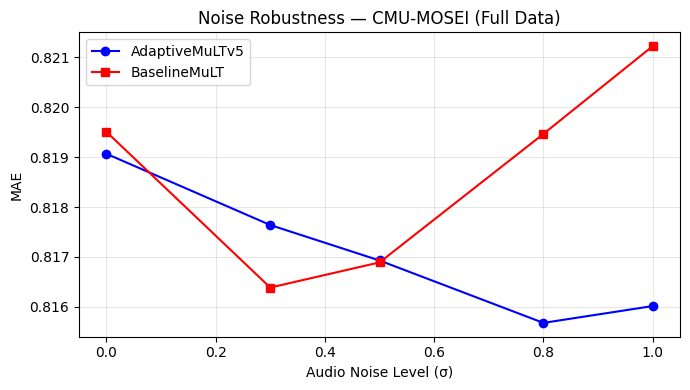

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.2685
   0.3        0.3951
   0.5        0.5100
   0.8        0.6776
   1.0        0.7706


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.1):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            if is_adaptive:
                out, *_ = model(audio, video, text, tau=tau)
            else:
                out = model(audio, video, text)
            preds.append(out.cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

# ── Clean test ────────────────────────────────────────────────────────────────
mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

# ── Noise robustness sweep ────────────────────────────────────────────────────
noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI (Full Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.1)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# ── Hyperparams ───────────────────────────────────────────────────────────────
EPOCHS            = 60
LR                = 3e-5      # between previous 5e-5 and 1e-4
LAMBDA_ENTROPY    = 0.01
LAMBDA_NOISE      = 0.15
LAMBDA_CONTRAST   = 0.7
LAMBDA_NOISY_TASK = 0.4
TAU_START         = 0.5       # start sharp since estimator is already trained
TAU_END           = 0.05
MAX_NOISE_START   = 1.0
MAX_NOISE_END     = 0.2
PATIENCE          = 20

# ── Reinitialise models fresh ─────────────────────────────────────────────────
adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)
sched_a = torch.optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=EPOCHS, eta_min=1e-6)
sched_b = torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=EPOCHS, eta_min=1e-6)
mse = torch.nn.MSELoss()

def safe_loss(loss_tensor, name="loss"):
    if torch.isnan(loss_tensor) or torch.isinf(loss_tensor):
        return None
    return loss_tensor

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(gates_clean, gates_noisy):
    kl_fwd = F.kl_div((gates_clean + 1e-8).log(), gates_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((gates_noisy + 1e-8).log(), gates_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

best_val_a = best_val_b = float('inf')
skipped_batches_a = skipped_batches_b = 0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    tau       = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    noise_est_errors = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            # Clean forward
            pred_clean, na_clean, nv_clean, nt_clean, gates_clean = \
                adaptive_model(audio, video, text, tau=tau)

            task_loss = safe_loss(mse(pred_clean, labels), "task_loss")
            if task_loss is None:
                skipped_batches_a += 1
                continue

            # Clean noise supervision: target = 0
            noise_clean_loss = mse(na_clean, torch.zeros(audio.size(0), device=device))

            # Noisy forward
            noise_level = torch.rand(audio.size(0), device=device) * max_noise + 0.05
            noisy_audio = audio + torch.randn_like(audio) * noise_level.view(-1, 1, 1)
            noisy_audio = torch.nan_to_num(noisy_audio, nan=0.0, posinf=10.0, neginf=-10.0)

            pred_noisy, na_noisy, nv_noisy, nt_noisy, gates_noisy = \
                adaptive_model(noisy_audio, video, text, tau=tau)

            noisy_task_loss = safe_loss(mse(pred_noisy, labels), "noisy_task")
            if noisy_task_loss is None:
                noisy_task_loss = torch.tensor(0.0, device=device)

            # Noisy noise supervision: target = noise_level
            noise_noisy_loss = mse(na_noisy, noise_level)
            noise_sup_loss   = (noise_clean_loss + noise_noisy_loss) / 2

            with torch.no_grad():
                noise_est_errors.append(
                    (na_noisy - noise_level).abs().mean().item())

            ent_loss      = entropy_loss(gates_clean)
            contrast_loss = contrastive_gate_loss(
                gates_clean[:, 0:1, :].detach(),
                gates_noisy[:, 0:1, :])

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task_loss
                      + LAMBDA_ENTROPY    * ent_loss
                      + LAMBDA_NOISE      * noise_sup_loss
                      + LAMBDA_CONTRAST   * contrast_loss)

            final_loss_a = safe_loss(loss_a, "total_loss_a")
            if final_loss_a is None:
                skipped_batches_a += 1
                continue

            final_loss_a.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  Adaptive batch {batch_idx} error: {e}")
            skipped_batches_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            loss_b = safe_loss(mse(pred_b, labels), "loss_b")
            if loss_b is None:
                skipped_batches_b += 1
                continue
            loss_b.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += loss_b.item()
            b_count += 1

        except Exception as e:
            print(f"  Baseline batch {batch_idx} error: {e}")
            skipped_batches_b += 1
            opt_b.zero_grad()
            continue

    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_preds, vb_preds, vlabels = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if (torch.isnan(audio).any() or torch.isnan(video).any() or
                    torch.isnan(text).any()):
                continue
            pred_a, *_ = adaptive_model(audio, video, text, tau=tau)
            pred_b     = baseline_model(audio, video, text)
            pred_a = torch.nan_to_num(pred_a, nan=0.0)
            pred_b = torch.nan_to_num(pred_b, nan=0.0)
            va_preds.append(pred_a.cpu())
            vb_preds.append(pred_b.cpu())
            vlabels.append(labels.cpu())

    if len(va_preds) == 0:
        print(f"Epoch {epoch:3d} — no valid validation batches, skipping.")
        continue

    va_preds  = torch.cat(va_preds)
    vb_preds  = torch.cat(vb_preds)
    vlabels   = torch.cat(vlabels)
    val_mae_a = (va_preds - vlabels).abs().mean().item()
    val_mae_b = (vb_preds - vlabels).abs().mean().item()

    improved = False
    if not (np.isnan(val_mae_a) or np.isinf(val_mae_a)) and val_mae_a < best_val_a:
        best_val_a = val_mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not (np.isnan(val_mae_b) or np.isinf(val_mae_b)) and val_mae_b < best_val_b:
        best_val_b = val_mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a    = a_loss_sum / a_count if a_count > 0 else float('nan')
        avg_b    = b_loss_sum / b_count if b_count > 0 else float('nan')
        avg_nest = np.mean(noise_est_errors) if noise_est_errors else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"TrainLoss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={val_mae_a:.4f} B={val_mae_b:.4f} | "
              f"BestA={best_val_a:.4f} BestB={best_val_b:.4f} | "
              f"NoiseEstErr={avg_nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nTraining complete. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Epoch   1/60 | τ=0.500 | LR=3.00e-05 | TrainLoss A=1.2657 B=1.2665 | ValMAE A=0.7777 B=0.7776 | BestA=0.7777 BestB=0.7776 | NoiseEstErr=0.2541 | NoImprove=0
Epoch   5/60 | τ=0.469 | LR=2.95e-05 | TrainLoss A=1.2206 B=1.1927 | ValMAE A=0.7642 B=0.7776 | BestA=0.7600 BestB=0.7706 | NoiseEstErr=0.2228 | NoImprove=1
Epoch  10/60 | τ=0.431 | LR=2.81e-05 | TrainLoss A=1.1884 B=1.1402 | ValMAE A=0.7572 B=0.7770 | BestA=0.7572 BestB=0.7706 | NoiseEstErr=0.1074 | NoImprove=0
Epoch  15/60 | τ=0.393 | LR=2.58e-05 | TrainLoss A=1.1706 B=1.1200 | ValMAE A=0.7705 B=0.7829 | BestA=0.7572 BestB=0.7706 | NoiseEstErr=0.0360 | NoImprove=5
Epoch  20/60 | τ=0.355 | LR=2.27e-05 | TrainLoss A=1.1465 B=1.0941 | ValMAE A=0.7755 B=0.7784 | BestA=0.7572 BestB=0.7706 | NoiseEstErr=0.0197 | NoImprove=10
Epoch  25/60 | τ=0.317 | LR=1.93e-05 | TrainLoss A=1.1343 B=1.0804 | ValMAE A=0.7803 B=0.7875 | BestA=0.7572 BestB=0.7706 | NoiseEstErr=0.0257 | NoImprove=15
Epoch  30/60 | τ=0.279 | LR=1.55e-05 |

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8172  Corr=0.2258  Acc2=0.6898
Baseline  MAE=0.8180  Corr=0.2218  Acc2=0.6229

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8154         0.8180      0.0027
   0.3         0.8153         0.8146     -0.0007
   0.5         0.8189         0.8188     -0.0000
   0.8         0.8156         0.8238      0.0081
   1.0         0.8167         0.8251      0.0084


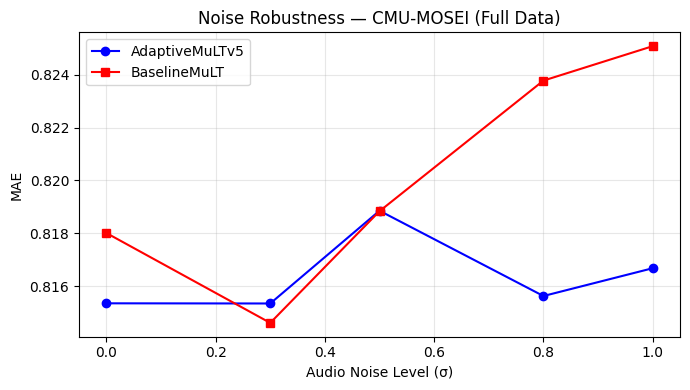

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.2323
   0.3        0.3566
   0.5        0.4702
   0.8        0.6440
   1.0        0.7441


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.1):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            if is_adaptive:
                out, *_ = model(audio, video, text, tau=tau)
            else:
                out = model(audio, video, text)
            preds.append(out.cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

# ── Clean test ────────────────────────────────────────────────────────────────
mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

# ── Noise robustness sweep ────────────────────────────────────────────────────
noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI (Full Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.1)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

trying to improve

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128    # doubled from 64
N_HEADS  = 8      # doubled from 4
N_LAYERS = 6      # increased from 4
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):           # x: (B, T, d_in)
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def forward(self, a, v, t):
        # use both mean and std as features — std captures noise better than mean
        def pool(x):
            return torch.cat([x.mean(dim=1), x.std(dim=1)], dim=-1)
        return (self.audio_est(pool(a)).squeeze(-1),
                self.video_est(pool(v)).squeeze(-1),
                self.text_est(pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)   # (B, 3, K)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        # Deeper fusion head
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)   # (B, K, d_model)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)

        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]

        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2

        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 7,556,353


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 400
MAX_V = 400

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout  # prob of zeroing a modality

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        # Modality dropout — randomly zero out audio or video
        # forces model to rely on gating rather than always using all modalities
        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 24   # reduced from 32 to fit larger model

train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.15)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)

    # Noise curriculum: start high, gradually focus on harder examples
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            # Clean forward
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            # Clean noise target = 0
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            # Noisy forward — sample from curriculum range
            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1,1,1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss  = mse(na_n, nl)
            noise_sup     = (n_clean_loss + n_noisy_loss) / 2
            ent           = entropy_loss(g_c)
            contrast      = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])

            # Also contrast video and text gates for richer signal
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast_all = (contrast + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast_all)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(mse(pred_b, labels), "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p = torch.cat(va_p)
    vb_p = torch.cat(vb_p)
    vl   = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632


/tmp/ipykernel_1096/1974360580.py:98: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  return torch.cat([x.mean(dim=1), x.std(dim=1)], dim=-1)
/tmp/ipykernel_1096/1165980165.py:160: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_a.step()
/tmp/ipykernel_1096/1165980165.py:161: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step

Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.00e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=4
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=9
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=14
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=19
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7823 | Best A=0.7772 B=0.7823 | NestErr=nan | NoImprove=24

Early stopping at epoch 26.

Done. Best Val MAE — Adaptive: 

RETRY

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
print(os.listdir(CSD_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['CMU_MOSEI_COVAREP.csd', 'CMU_MOSEI_TimestampedWords.csd', 'CMU_MOSEI_TimestampedWords.csd.4', 'CMU_MOSEI_TimestampedWords.csd.3', 'CMU_MOSEI_TimestampedWords.csd.1', 'CMU_MOSEI_VisualFacet42.csd', 'CMU_MOSEI_Labels.csd', 'CMU_MOSEI_Labels.csd.5', 'CMU_MOSEI_Labels.csd.4', 'CMU_MOSEI_Labels.csd.1', 'CMU_MOSEI_COVAREP.csd.1', 'CMU_MOSEI_VisualFacet42.csd.1', 'CMU_MOSEI_COVAREP.csd.2', 'CMU_MOSEI_TimestampedWords.csd.2', 'CMU_MOSEI_Labels.csd.2', 'CMU_MOSEI_COVAREP.csd.3', 'CMU_MOSEI_VisualFacet42.csd.2', 'CMU_MOSEI_Labels.csd.3', 'CMU_MOSEI_COVAREP.csd.4', 'CMU_MOSEI_VisualFacet42.csd.3', 'CMU_MOSEI_COVAREP.csd.5', 'CMU_MOSEI_VisualFacet42.csd.4', 'CMU_MOSEI_TimestampedWords.csd.5', 'label.csv', 'bert_embeddings.pkl', 'noise_robustness_v4.png', 'best_model.pt', 'training_curves.png', 'best_adaptive.pt', 'best_baseline.pt', 'comparison.png', 'adaptive_detail.p

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
!pip install -q transformers

  Preparing metadata (setup.py) ... done


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'
BERT_CACHE   = CSD_DIR + 'bert_embeddings_full.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 7,556,353


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 400
MAX_V = 400

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 24
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.15)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1,1,1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(mse(pred_b, labels), "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        # step schedulers after optimizer steps
        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=5.00e-07 | Loss A=1.2739 B=1.2707 | ValMAE A=0.7779 B=0.7778 | Best A=0.7779 B=0.7778 | NestErr=0.2924 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=1.25e-05 | Loss A=1.2710 B=1.2707 | ValMAE A=0.7778 B=0.7778 | Best A=0.7778 B=0.7777 | NestErr=0.1018 | NoImprove=0
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=8.27e-06 | Loss A=1.2636 B=1.2655 | ValMAE A=0.7770 B=0.7775 | Best A=0.7770 B=0.7775 | NestErr=0.0631 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.2124 B=1.2098 | ValMAE A=0.7553 B=0.7703 | Best A=0.7553 B=0.7579 | NestErr=0.0417 | NoImprove=0
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=2.76e-05 | Loss A=1.2061 B=1.1900 | ValMAE A=0.7599 B=0.7745 | Best A=0.7509 B=0.7579 | NestErr=0.0298 | NoImprove=4
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=5.46e-07 | Loss A=1.1984 B=1.1725 | ValMAE A=0.7624 B=0.7848 | Best A=0.7509 B=0.7

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8081  Corr=0.2225  Acc2=0.5915
Baseline  MAE=0.8109  Corr=0.2252  Acc2=0.6637

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8081         0.8109      0.0029
   0.3         0.8083         0.8105      0.0023
   0.5         0.8083         0.8107      0.0023
   0.8         0.8083         0.8117      0.0034
   1.0         0.8082         0.8117      0.0035


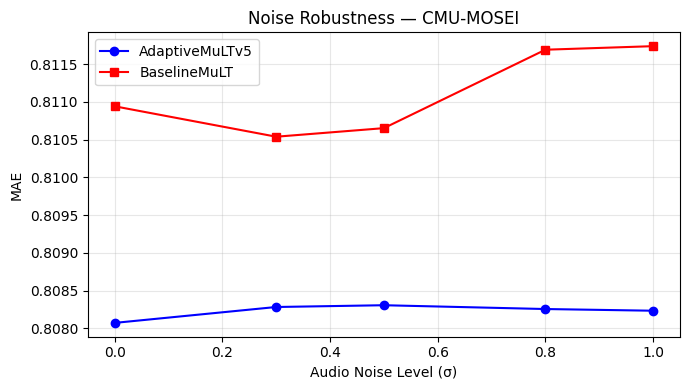

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.0171
   0.3        0.2297
   0.5        0.4219
   0.8        0.7002
   1.0        0.7975


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.05)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
print(os.listdir(CSD_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['CMU_MOSEI_COVAREP.csd', 'CMU_MOSEI_TimestampedWords.csd', 'CMU_MOSEI_TimestampedWords.csd.4', 'CMU_MOSEI_TimestampedWords.csd.3', 'CMU_MOSEI_TimestampedWords.csd.1', 'CMU_MOSEI_VisualFacet42.csd', 'CMU_MOSEI_Labels.csd', 'CMU_MOSEI_Labels.csd.5', 'CMU_MOSEI_Labels.csd.4', 'CMU_MOSEI_Labels.csd.1', 'CMU_MOSEI_COVAREP.csd.1', 'CMU_MOSEI_VisualFacet42.csd.1', 'CMU_MOSEI_COVAREP.csd.2', 'CMU_MOSEI_TimestampedWords.csd.2', 'CMU_MOSEI_Labels.csd.2', 'CMU_MOSEI_COVAREP.csd.3', 'CMU_MOSEI_VisualFacet42.csd.2', 'CMU_MOSEI_Labels.csd.3', 'CMU_MOSEI_COVAREP.csd.4', 'CMU_MOSEI_VisualFacet42.csd.3', 'CMU_MOSEI_COVAREP.csd.5', 'CMU_MOSEI_VisualFacet42.csd.4', 'CMU_MOSEI_TimestampedWords.csd.5', 'label.csv', 'bert_embeddings.pkl', 'noise_robustness_v4.png', 'best_model.pt', 'training_curves.png', 'best_adaptive.pt', 'best_baseline.pt', 'comparison.png', 'adaptive_detail.p

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
!pip install -q transformers

  Preparing metadata (setup.py) ... done


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'
BERT_CACHE   = CSD_DIR + 'bert_embeddings_full.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 7,556,353


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 400
MAX_V = 400

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 24
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)

            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=5.00e-07 | Loss A=1.2723 B=1.4556 | ValMAE A=0.7776 B=0.7776 | Best A=0.7776 B=0.7776 | NestErr=0.2890 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=1.25e-05 | Loss A=1.2661 B=1.4495 | ValMAE A=0.7778 B=0.7778 | Best A=0.7776 B=0.7776 | NestErr=0.1074 | NoImprove=4
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=8.27e-06 | Loss A=1.2666 B=1.4483 | ValMAE A=0.7777 B=0.7777 | Best A=0.7776 B=0.7776 | NestErr=0.0678 | NoImprove=9
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.2056 B=1.4239 | ValMAE A=0.7571 B=0.7575 | Best A=0.7514 B=0.7575 | NestErr=0.0440 | NoImprove=0
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=2.76e-05 | Loss A=1.1781 B=1.3750 | ValMAE A=0.7598 B=0.7626 | Best A=0.7514 B=0.7568 | NestErr=0.0316 | NoImprove=4
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=5.46e-07 | Loss A=1.1511 B=1.3467 | ValMAE A=0.7693 B=0.7653 | Best A=0.7514 B=0.7

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8102  Corr=0.2271  Acc2=0.6989
Baseline  MAE=0.8107  Corr=0.2331  Acc2=0.6519

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8102         0.8107      0.0005
   0.3         0.8102         0.8100     -0.0003
   0.5         0.8105         0.8104     -0.0000
   0.8         0.8106         0.8109      0.0003
   1.0         0.8107         0.8114      0.0007


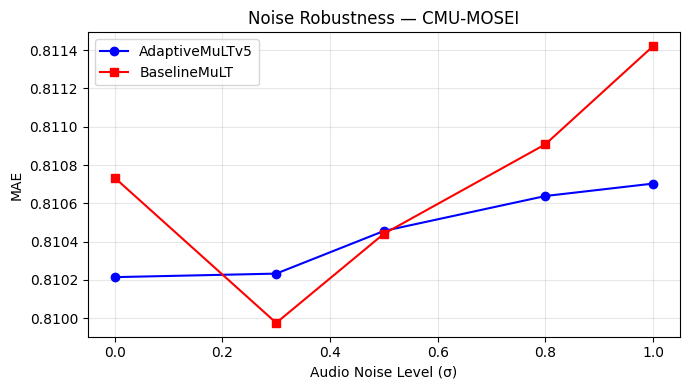

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.0222
   0.3        0.2757
   0.5        0.4885
   0.8        0.7115
   1.0        0.7923


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.05)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

GOOD RUN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
print(os.listdir(CSD_DIR))

Mounted at /content/drive
['CMU_MOSEI_COVAREP.csd', 'CMU_MOSEI_TimestampedWords.csd', 'CMU_MOSEI_TimestampedWords.csd.4', 'CMU_MOSEI_TimestampedWords.csd.3', 'CMU_MOSEI_TimestampedWords.csd.1', 'CMU_MOSEI_VisualFacet42.csd', 'CMU_MOSEI_Labels.csd', 'CMU_MOSEI_Labels.csd.5', 'CMU_MOSEI_Labels.csd.4', 'CMU_MOSEI_Labels.csd.1', 'CMU_MOSEI_COVAREP.csd.1', 'CMU_MOSEI_VisualFacet42.csd.1', 'CMU_MOSEI_COVAREP.csd.2', 'CMU_MOSEI_TimestampedWords.csd.2', 'CMU_MOSEI_Labels.csd.2', 'CMU_MOSEI_COVAREP.csd.3', 'CMU_MOSEI_VisualFacet42.csd.2', 'CMU_MOSEI_Labels.csd.3', 'CMU_MOSEI_COVAREP.csd.4', 'CMU_MOSEI_VisualFacet42.csd.3', 'CMU_MOSEI_COVAREP.csd.5', 'CMU_MOSEI_VisualFacet42.csd.4', 'CMU_MOSEI_TimestampedWords.csd.5', 'label.csv', 'bert_embeddings.pkl', 'noise_robustness_v4.png', 'best_model.pt', 'training_curves.png', 'best_adaptive.pt', 'best_baseline.pt', 'comparison.png', 'adaptive_detail.png', 'noise_robustness.png', 'final_adaptive.pt', 'final_baseline.pt', 'best_adaptive_v4.pt', 'best_bas

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
!pip install -q transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'
BERT_CACHE   = CSD_DIR + 'bert_embeddings_full.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)

# Collect all labels from train split
labels = [entry['label'] for entry in aligned['train'].values()]
labels = np.array(labels)

print(f"Min:    {labels.min():.4f}")
print(f"Max:    {labels.max():.4f}")
print(f"Mean:   {labels.mean():.4f}")
print(f"Std:    {labels.std():.4f}")
print(f"Median: {np.median(labels):.4f}")

# Distribution across sentiment range
bins = [-3, -2, -1, 0, 1, 2, 3]
counts, edges = np.histogram(labels, bins=bins)
print("\nDistribution:")
for i in range(len(counts)):
    print(f"  [{edges[i]:.0f}, {edges[i+1]:.0f}]: {counts[i]} samples")

# Positive vs negative split
print(f"\nPositive (>=0): {(labels >= 0).sum()} ({(labels >= 0).mean()*100:.1f}%)")
print(f"Negative  (<0): {(labels  < 0).sum()} ({(labels  < 0).mean()*100:.1f}%)")

Min:    -3.0000
Max:    3.0000
Mean:   0.1463
Std:    1.1245
Median: 0.0000

Distribution:
  [-3, -2]: 613 samples
  [-2, -1]: 1583 samples
  [-1, 0]: 2542 samples
  [0, 1]: 7483 samples
  [1, 2]: 3084 samples
  [2, 3]: 1017 samples

Positive (>=0): 11584 (71.0%)
Negative  (<0): 4738 (29.0%)


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)

# Check a few samples
samples = list(aligned['train'].items())[:5]
for sid, entry in samples:
    print(f"ID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")
    print()

# Check sequence length distributions across full train set
audio_lengths = [entry['audio'].shape[0] for entry in aligned['train'].values()]
video_lengths = [entry['video'].shape[0] for entry in aligned['train'].values()]

print("── Audio sequence lengths ───────────────────────")
print(f"  Min:    {np.min(audio_lengths)}")
print(f"  Max:    {np.max(audio_lengths)}")
print(f"  Mean:   {np.mean(audio_lengths):.1f}")
print(f"  Median: {np.median(audio_lengths):.1f}")
print(f"  Std:    {np.std(audio_lengths):.1f}")

print("\n── Video sequence lengths ───────────────────────")
print(f"  Min:    {np.min(video_lengths)}")
print(f"  Max:    {np.max(video_lengths)}")
print(f"  Mean:   {np.mean(video_lengths):.1f}")
print(f"  Median: {np.median(video_lengths):.1f}")
print(f"  Std:    {np.std(video_lengths):.1f}")

# Check feature dimensions
sample = list(aligned['train'].values())[0]
print(f"\n── Feature dimensions ───────────────────────────")
print(f"  Audio: {sample['audio'].shape[1]}d")
print(f"  Video: {sample['video'].shape[1]}d")

# Check what percentage exceed your MAX_A and MAX_V cutoffs
MAX_A = 400
MAX_V = 400
print(f"\n── Sequences exceeding max length ───────────────")
print(f"  Audio > {MAX_A}: {(np.array(audio_lengths) > MAX_A).sum()} "
      f"({(np.array(audio_lengths) > MAX_A).mean()*100:.1f}%)")
print(f"  Video > {MAX_V}: {(np.array(video_lengths) > MAX_V).sum()} "
      f"({(np.array(video_lengths) > MAX_V).mean()*100:.1f}%)")

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000

ID: -3g5yACwYnA[3]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000

ID: -3g5yACwYnA[4]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

── Audio sequence lengths ───────────────────────
  Min:    1
  Max:    1
  Mean:   1.0
  Median: 1.0
  Std:    0.0

── Video sequence lengths ───────────────────────
  Min:    1
  Max:    1
  Mean:   1.0
  Median: 1.0
  Std:    0.0

── Feature dimensions ───────────────────────────
  Audio: 74d
  Video: 35d

── Sequences exceeding max length ───────────────
  Audio > 400: 0 (0.0%)
  Video > 400: 0 (0.0%)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64,       # smaller — matches original MuLT
                 n_heads=4,
                 n_layers=4,
                 dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 400
MAX_V = 400

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 24
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)

            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=5.00e-07 | Loss A=1.2684 B=1.4483 | ValMAE A=0.7779 B=0.7777 | Best A=0.7779 B=0.7777 | NestErr=0.2870 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=1.25e-05 | Loss A=1.2669 B=1.4477 | ValMAE A=0.7780 B=0.7779 | Best A=0.7779 B=0.7777 | NestErr=0.1077 | NoImprove=3
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=8.27e-06 | Loss A=1.2708 B=1.4266 | ValMAE A=0.7780 B=0.7697 | Best A=0.7777 B=0.7697 | NestErr=0.0744 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.2107 B=1.3689 | ValMAE A=0.7581 B=0.7750 | Best A=0.7564 B=0.7661 | NestErr=0.0453 | NoImprove=1
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=2.76e-05 | Loss A=1.1801 B=1.3491 | ValMAE A=0.7653 B=0.7641 | Best A=0.7564 B=0.7633 | NestErr=0.0322 | NoImprove=1
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=5.46e-07 | Loss A=1.1671 B=1.3293 | ValMAE A=0.7665 B=0.7648 | Best A=0.7564 B=0.7

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8108  Corr=0.2064  Acc2=0.7102
Baseline  MAE=0.8113  Corr=0.2676  Acc2=0.6815

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8108         0.8113      0.0005
   0.3         0.8102         0.8126      0.0024
   0.5         0.8101         0.8193      0.0093
   0.8         0.8099         0.8233      0.0133
   1.0         0.8099         0.8251      0.0152


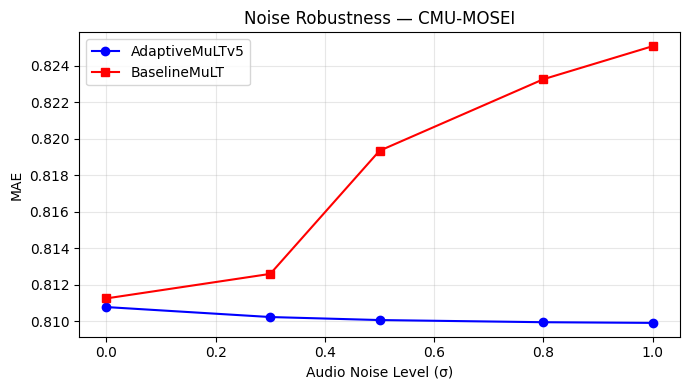

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.0203
   0.3        0.2708
   0.5        0.4956
   0.8        0.7534
   1.0        0.8212


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.05)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

In [ ]:
# ── Fine-tune from best checkpoint with higher sign loss ─────────────────────
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))

# Evaluate current best to set starting point
def quick_val(model, is_adaptive=True, tau=0.05):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out).cpu())
            labs.append(labels)
    p = torch.cat(preds)
    l = torch.cat(labs)
    return (p - l).abs().mean().item()

best_val_a = quick_val(adaptive_model, is_adaptive=True)
best_val_b = quick_val(baseline_model, is_adaptive=False)
print(f"Resuming from BestA={best_val_a:.4f}  BestB={best_val_b:.4f}")

FINETUNE_EPOCHS = 20
LR_FT           = 1e-5     # low LR to avoid catastrophic forgetting
LAMBDA_SIGN_FT  = 0.6      # higher sign loss to improve Corr
LAMBDA_NOISE    = 0.2
LAMBDA_CONTRAST = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_ENTROPY  = 0.02
PATIENCE        = 10

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR_FT, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR_FT, weight_decay=1e-4)
mse   = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

TAU      = 0.05   # stay sharp throughout fine-tuning
epochs_no_improve = 0

for epoch in range(1, FINETUNE_EPOCHS + 1):
    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0

    for audio, video, text, labels in train_loader:
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # Adaptive
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=TAU)
            task_loss = safe_loss(mse(pred_c, labels))
            if task_loss is None:
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * 0.9 + 0.05
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1,1,1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_n, na_n, _, _, g_n = adaptive_model(n_audio, video, text, tau=TAU)

            noisy_task   = safe_loss(mse(pred_n, labels)) or torch.tensor(0.0, device=device)
            noise_sup    = (n_clean_loss + mse(na_n, nl)) / 2
            ent          = entropy_loss(g_c)
            contrast     = (contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:]) +
                            contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:]) +
                            contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])) / 3

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN_FT    * sign_l)

            fl = safe_loss(loss_a)
            if fl is None:
                continue
            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1
        except Exception:
            opt_a.zero_grad()
            continue

        # Baseline
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(mse(pred_b, labels) + LAMBDA_SIGN_FT * sign_loss(pred_b, labels))
            if lb is None:
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception:
            opt_b.zero_grad()
            continue

    # Validation
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []
    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=TAU)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa).cpu())
            vb_p.append(torch.nan_to_num(pb).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v5.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v5.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    avg_a = a_loss_sum / a_count if a_count else float('nan')
    avg_b = b_loss_sum / b_count if b_count else float('nan')
    print(f"FT Epoch {epoch:2d}/{FINETUNE_EPOCHS} | "
          f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
          f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
          f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
          f"NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at FT epoch {epoch}.")
        break

print(f"\nFine-tuning complete. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")
print("Now run Cell 7 to see updated test results.")

Resuming from BestA=0.7564  BestB=0.7604
FT Epoch  1/20 | Loss A=1.3398 B=1.8962 | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=0
FT Epoch  2/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=1
FT Epoch  3/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=2
FT Epoch  4/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=3
FT Epoch  5/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=4
FT Epoch  6/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=5
FT Epoch  7/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=6
FT Epoch  8/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=7
FT Epoch  9/20 | Loss A=nan B=nan | ValMAE A=0.7772 B=0.7604 | Best A=0.7564 B=0.7604 | NoImprove=8
FT Epoch 10/20 | Loss A=nan B=nan | ValMAE A=0.7772 B

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8108  Corr=0.2064  Acc2=0.7102
Baseline  MAE=0.8111  Corr=0.2672  Acc2=0.6774

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8108         0.8111      0.0004
   0.3         0.8102         0.8137      0.0034
   0.5         0.8101         0.8204      0.0103
   0.8         0.8099         0.8247      0.0147
   1.0         0.8099         0.8257      0.0158


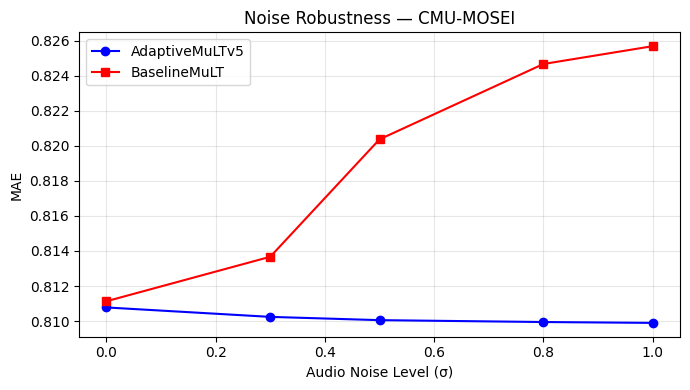

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio
   0.0        0.0203
   0.3        0.2708
   0.5        0.4957
   0.8        0.7535
   1.0        0.8212


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_v5.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_v5.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]
results = {'adaptive': [], 'baseline': []}

print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, results['adaptive'], 'b-o', label='AdaptiveMuLTv5')
plt.plot(noise_levels, results['baseline'], 'r-s', label='BaselineMuLT')
plt.xlabel('Audio Noise Level (σ)')
plt.ylabel('MAE')
plt.title('Noise Robustness — CMU-MOSEI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_v5_full.png', dpi=150)
plt.show()
print("Plot saved.")

print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=24, shuffle=False, num_workers=2)
    ests = []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, _, _, _ = adaptive_model(audio, video, text, tau=0.05)
            ests.append(na.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(ests):>12.4f}")

TEMPORAL

In [ ]:
import pickle
import numpy as np
from mmsdk import mmdatasdk

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

print("Loading CSD files...")
dataset = mmdatasdk.mmdataset({
    'COVAREP':       CSD_DIR + 'CMU_MOSEI_COVAREP.csd',
    'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd',
}, CSD_DIR)
dataset.add_computational_sequences(
    {'All Labels': CSD_DIR + 'CMU_MOSEI_Labels.csd'}, CSD_DIR)

# Use avg only for labels, not for audio/video
def avg(intervals, features):
    return np.average(features, axis=0)

print("Aligning to labels...")
dataset.align('All Labels', collapse_functions=[avg])

all_ids    = list(dataset['COVAREP'].data.keys())
train_fold = set(mmdatasdk.cmu_mosei.standard_folds.standard_train_fold)
valid_fold = set(mmdatasdk.cmu_mosei.standard_folds.standard_valid_fold)
test_fold  = set(mmdatasdk.cmu_mosei.standard_folds.standard_test_fold)

print(f"Total aligned: {len(all_ids)}")

aligned = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
audio_lengths = []

for sid in all_ids:
    try:
        audio = dataset['COVAREP'][sid]['features']
        video = dataset['VisualFacet42'][sid]['features']
        label = float(dataset['All Labels'][sid]['features'][0, 0])

        # Skip degenerate samples
        if audio.shape[0] == 0 or video.shape[0] == 0:
            skipped += 1
            continue

        entry = {
            'audio': audio.astype(np.float32),
            'video': video.astype(np.float32),
            'label': label,
        }
        audio_lengths.append(audio.shape[0])

        vid = sid.split('[')[0]
        if vid in train_fold:
            aligned['train'][sid] = entry
        elif vid in valid_fold:
            aligned['valid'][sid] = entry
        elif vid in test_fold:
            aligned['test'][sid] = entry
        else:
            aligned['unassigned'][sid] = entry

    except Exception as e:
        skipped += 1

print(f"Train: {len(aligned['train'])} | Valid: {len(aligned['valid'])} | "
      f"Test: {len(aligned['test'])} | Unassigned: {len(aligned['unassigned'])} | Skipped: {skipped}")
print(f"Audio lengths — Min: {np.min(audio_lengths)} Max: {np.max(audio_lengths)} "
      f"Mean: {np.mean(audio_lengths):.1f} Median: {np.median(audio_lengths):.1f}")

with open(ALIGNED_PATH, 'wb') as f:
    pickle.dump(aligned, f)
print(f"Saved to {ALIGNED_PATH}")

Loading CSD files...
[2026-04-05 12:51:42.390] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-04-05 12:56:42.204] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-04-05 12:56:42.204] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-05 12:57:42.151] | Success | <COVAREP> computational sequence data in correct format.
[2026-04-05 12:57:42.152] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-05 12:57:42.152] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-05 12:57:43.622] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-04-05 12:58:34.006] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-04-05 12:58:34.006] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-04-05 12:58:43.414] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-04-05 12:58:43.415] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-04-05 12:58:43.415] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-04-05 12:58:43.415] | Success | Dataset initialized successfully ... 
[2026-04-05 12:58:44.679] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd ...
[2026-04-05 12:59:00.236] | Status  | Checking the integrity of the <All Labels> computational sequence ...
[2026-04-05 12:59:00.236] | Status  | Checking the format of the data in <All Labels> computational sequence ...


[2026-04-05 12:59:01.717] | Success | <All Labels> computational sequence data in correct format.
[2026-04-05 12:59:01.717] | Status  | Checking the format of the metadata in <All Labels> computational sequence ...
[2026-04-05 12:59:01.717] | Warning | <All Labels> computational sequence does not have all the required metadata ... continuing 
Aligning to labels...
[2026-04-05 12:59:01.718] | Status  | Unify was called ...
[2026-04-05 12:59:01.722] | Warning | 34684 entry is not shared among all sequences, removing it ...
[2026-04-05 12:59:01.724] | Warning | 226602 entry is not shared among all sequences, removing it ...
[2026-04-05 12:59:01.725] | Warning | 24157 entry is not shared among all sequences, removing it ...
[2026-04-05 12:59:01.726] | Warning | 188004 entry is not shared among all sequences, removing it ...
[2026-04-05 12:59:01.728] | Warning | 178941 entry is not shared among all sequences, removing it ...
[2026-04-05 12:59:01.729] | Warning | 192827 entry is not shared a

Streaming output truncated to the last 5000 lines.
Streaming output truncated to the last 5000 lines.
                                                                   
Aligning QEG_hkJsaYc:   0%|          | 0/1 [00:00<?, ? Segments/s]
                                                                  
Aligning QIonRUsCqBs:   0%|          | 0/4 [00:00<?, ? Segments/s]
                                                                  
Aligning QJBQIOmG1CA:   0%|          | 0/1 [00:00<?, ? Segments/s]
                                                                  
Aligning QJCDZCllSYQ:   0%|          | 0/3 [00:00<?, ? Segments/s]
                                                                  
Aligning QLEOYF7Mju0:   0%|          | 0/11 [00:00<?, ? Segments/s]
                                                                   
Aligning QLI-OnegxFM:   0%|          | 0/2 [00:00<?, ? Segments/s]
                                                                  
Aligning QMEgjkpyVzQ:   

[2026-04-05 13:04:43.130] | Success | Alignment to <All Labels> complete.
[2026-04-05 13:04:43.130] | Status  | Replacing dataset content with aligned computational sequences
[2026-04-05 13:04:43.190] | Success | Initialized empty <COVAREP> computational sequence.
[2026-04-05 13:04:43.640] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-05 13:04:43.971] | Success | <COVAREP> computational sequence data in correct format.


[2026-04-05 13:04:44.168] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-05 13:04:44.168] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-05 13:04:44.169] | Success | Initialized empty <VisualFacet42> computational sequence.
[2026-04-05 13:04:44.169] | Status  | Checking the format of the data in <VisualFacet42> computational sequence ...


[2026-04-05 13:04:44.208] | Success | <VisualFacet42> computational sequence data in correct format.
[2026-04-05 13:04:44.208] | Status  | Checking the format of the metadata in <VisualFacet42> computational sequence ...
[2026-04-05 13:04:44.208] | Warning | <VisualFacet42> computational sequence does not have all the required metadata ... continuing 
[2026-04-05 13:04:44.208] | Success | Initialized empty <All Labels> computational sequence.
[2026-04-05 13:04:44.209] | Status  | Checking the format of the data in <All Labels> computational sequence ...


[2026-04-05 13:04:44.247] | Success | <All Labels> computational sequence data in correct format.
[2026-04-05 13:04:44.247] | Status  | Checking the format of the metadata in <All Labels> computational sequence ...
[2026-04-05 13:04:44.247] | Warning | <All Labels> computational sequence does not have all the required metadata ... continuing 
Total aligned: 23248
Train: 16322 | Valid: 1871 | Test: 4659 | Unassigned: 388 | Skipped: 8
Audio lengths — Min: 1 Max: 1 Mean: 1.0 Median: 1.0
Saved to /content/drive/MyDrive/CMU_MOSEI/mosei_full_aligned_temporal.pkl


In [ ]:
import pickle
import numpy as np

CSD_DIR      = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE   = CSD_DIR + 'bert_embeddings_full.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

# Check sequence length distributions
audio_lengths = [entry['audio'].shape[0] for entry in aligned['train'].values()]
video_lengths = [entry['video'].shape[0] for entry in aligned['train'].values()]

print(f"\n── Audio sequence lengths ───────────────────────")
print(f"  Min: {np.min(audio_lengths)}  Max: {np.max(audio_lengths)}  "
      f"Mean: {np.mean(audio_lengths):.1f}  Median: {np.median(audio_lengths):.1f}")
print(f"\n── Video sequence lengths ───────────────────────")
print(f"  Min: {np.min(video_lengths)}  Max: {np.max(video_lengths)}  "
      f"Mean: {np.mean(video_lengths):.1f}  Median: {np.median(video_lengths):.1f}")

MAX_A = int(np.percentile(audio_lengths, 95))
MAX_V = int(np.percentile(video_lengths, 95))
print(f"\n── Suggested max lengths (95th percentile) ──────")
print(f"  MAX_A: {MAX_A}")
print(f"  MAX_V: {MAX_V}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000

── Audio sequence lengths ───────────────────────
  Min: 1  Max: 1  Mean: 1.0  Median: 1.0

── Video sequence lengths ───────────────────────
  Min: 1  Max: 1  Mean: 1.0  Median: 1.0

── Suggested max lengths (95th percentile) ──────
  MAX_A: 1
  MAX_V: 1


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Update these after running Cell 4
MAX_A = 100   # update based on 95th percentile from Cell 4
MAX_V = 100   # update based on 95th percentile from Cell 4

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 16   # reduced from 24 to handle longer sequences
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=100  MAX_V=100  BATCH=16


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

# ── Clean test ────────────────────────────────────────────────────────────────
mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Text noise ────────────────────────────────────────────────────────────────
results_t = {'adaptive': [], 'baseline': []}
print("\n── Text Noise Robustness ───────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='text')
    ldr = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_t['adaptive'].append(ma)
    results_t['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_t, results_all],
        ['Audio Noise', 'Video Noise', 'Text Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness Across Modalities — CMU-MOSEI')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_all_modalities.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration — All Modalities ─")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
print(os.listdir(CSD_DIR))

Mounted at /content/drive
['CMU_MOSEI_COVAREP.csd', 'CMU_MOSEI_TimestampedWords.csd', 'CMU_MOSEI_TimestampedWords.csd.4', 'CMU_MOSEI_TimestampedWords.csd.3', 'CMU_MOSEI_TimestampedWords.csd.1', 'CMU_MOSEI_VisualFacet42.csd', 'CMU_MOSEI_Labels.csd', 'CMU_MOSEI_Labels.csd.5', 'CMU_MOSEI_Labels.csd.4', 'CMU_MOSEI_Labels.csd.1', 'CMU_MOSEI_COVAREP.csd.1', 'CMU_MOSEI_VisualFacet42.csd.1', 'CMU_MOSEI_COVAREP.csd.2', 'CMU_MOSEI_TimestampedWords.csd.2', 'CMU_MOSEI_Labels.csd.2', 'CMU_MOSEI_COVAREP.csd.3', 'CMU_MOSEI_VisualFacet42.csd.2', 'CMU_MOSEI_Labels.csd.3', 'CMU_MOSEI_COVAREP.csd.4', 'CMU_MOSEI_VisualFacet42.csd.3', 'CMU_MOSEI_COVAREP.csd.5', 'CMU_MOSEI_VisualFacet42.csd.4', 'CMU_MOSEI_TimestampedWords.csd.5', 'label.csv', 'bert_embeddings.pkl', 'noise_robustness_v4.png', 'best_model.pt', 'training_curves.png', 'best_adaptive.pt', 'best_baseline.pt', 'comparison.png', 'adaptive_detail.png', 'noise_robustness.png', 'final_adaptive.pt', 'final_baseline.pt', 'best_adaptive_v4.pt', 'best_bas

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
!pip install -q transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
from mmsdk import mmdatasdk

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

print("Loading raw CSD files (takes ~10 mins)...")
raw_audio = mmdatasdk.mmdataset({'COVAREP': CSD_DIR + 'CMU_MOSEI_COVAREP.csd'}, CSD_DIR)
raw_video = mmdatasdk.mmdataset({'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd'}, CSD_DIR)

covarep_data = raw_audio['COVAREP'].data
facet_data   = raw_video['VisualFacet42'].data

print(f"Raw audio entries: {len(covarep_data)}")
print(f"Raw video entries: {len(facet_data)}")

Loading raw CSD files (takes ~10 mins)...
[2026-04-06 01:27:20.731] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-04-06 01:52:48.297] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-04-06 01:52:48.297] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-06 02:01:26.768] | Success | <COVAREP> computational sequence data in correct format.
[2026-04-06 02:01:26.768] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-06 02:01:26.768] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-06 02:01:26.768] | Success | Dataset initialized successfully ... 
[2026-04-06 02:01:28.158] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-04-06 02:04:07.998] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-04-06 02:04:07.998] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-04-06 02:04:38.980] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-04-06 02:04:38.980] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-04-06 02:04:38.980] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-04-06 02:04:38.980] | Success | Dataset initialized successfully ... 
Raw audio entries: 3836
Raw video entries: 3837


In [ ]:
import pickle
import numpy as np
from collections import defaultdict

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH  = CSD_DIR + 'mosei_full_aligned.pkl'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned_avg = pickle.load(f)

vid_to_sids = defaultdict(list)
for sp in aligned_avg.values():
    for sid in sp.keys():
        vid_to_sids[sid.split('[')[0]].append(sid)

print(f"Unique videos: {len(vid_to_sids)}")

aligned_temporal = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
audio_lengths = []

for split in ['train', 'valid', 'test', 'unassigned']:
    for sid, entry in aligned_avg[split].items():
        try:
            vid = sid.split('[')[0]
            if vid not in covarep_data or vid not in facet_data:
                skipped += 1
                continue

            audio_full = covarep_data[vid]['features'].astype(np.float32)
            video_full = facet_data[vid]['features'].astype(np.float32)

            seg_idx        = int(sid.split('[')[1].replace(']', ''))
            n_segs         = len(vid_to_sids[vid])
            n_total_frames = audio_full.shape[0]

            frames_per_seg = max(1, n_total_frames // n_segs)
            start = seg_idx * frames_per_seg
            end   = start + frames_per_seg if seg_idx < n_segs - 1 else n_total_frames

            audio_seg = audio_full[start:end]
            video_seg = video_full[min(start, video_full.shape[0]-1):
                                   min(end,   video_full.shape[0])]

            if audio_seg.shape[0] == 0 or video_seg.shape[0] == 0:
                skipped += 1
                continue

            aligned_temporal[split][sid] = {
                'audio': audio_seg,
                'video': video_seg,
                'label': entry['label'],
            }
            if split == 'train':
                audio_lengths.append(audio_seg.shape[0])

        except Exception:
            skipped += 1
            continue

print(f"Train: {len(aligned_temporal['train'])} | Valid: {len(aligned_temporal['valid'])} | "
      f"Test: {len(aligned_temporal['test'])} | Skipped: {skipped}")
print(f"Audio lengths — Min: {np.min(audio_lengths)}  Max: {np.max(audio_lengths)}  "
      f"Mean: {np.mean(audio_lengths):.1f}  Median: {np.median(audio_lengths):.1f}")

with open(TEMPORAL_PATH, 'wb') as f:
    pickle.dump(aligned_temporal, f)
print(f"Saved to {TEMPORAL_PATH}")

Unique videos: 3291
Train: 16321 | Valid: 1871 | Test: 4659 | Skipped: 1
Audio lengths — Min: 257  Max: 68524  Mean: 1740.3  Median: 953.0
Saved to /content/drive/MyDrive/CMU_MOSEI/mosei_full_aligned_temporal.pkl


In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16321  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (2412, 74)
  Video shape: (2412, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (2412, 74)
  Video shape: (1928, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (2412, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 50
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.61e-06 | Loss A=1.2584 B=1.4324 | ValMAE A=0.7735 B=0.7720 | Best A=0.7735 B=0.7720 | NestErr=0.3525 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.1683 B=1.3703 | ValMAE A=0.7612 B=0.7898 | Best A=0.7612 B=0.7715 | NestErr=0.1558 | NoImprove=0
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.1178 B=1.3217 | ValMAE A=0.7540 B=0.7617 | Best A=0.7540 B=0.7617 | NestErr=0.1046 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.0772 B=1.2956 | ValMAE A=0.7631 B=0.7680 | Best A=0.7532 B=0.7569 | NestErr=0.0859 | NoImprove=3
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.0571 B=1.2767 | ValMAE A=0.7588 B=0.7667 | Best A=0.7522 B=0.7540 | NestErr=0.0727 | NoImprove=1
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0304 B=1.2539 | ValMAE A=0.7626 B=0

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
from mmsdk import mmdatasdk

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

print("Loading raw CSD files (takes ~10 mins)...")
raw_audio = mmdatasdk.mmdataset({'COVAREP': CSD_DIR + 'CMU_MOSEI_COVAREP.csd'}, CSD_DIR)
raw_video = mmdatasdk.mmdataset({'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd'}, CSD_DIR)

covarep_data = raw_audio['COVAREP'].data
facet_data   = raw_video['VisualFacet42'].data

print(f"Raw audio entries: {len(covarep_data)}")
print(f"Raw video entries: {len(facet_data)}")

Loading raw CSD files (takes ~10 mins)...
[2026-04-06 22:55:28.656] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-04-06 23:15:30.663] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-04-06 23:15:30.663] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-06 23:22:39.393] | Success | <COVAREP> computational sequence data in correct format.
[2026-04-06 23:22:39.393] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-06 23:22:39.393] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-06 23:22:39.393] | Success | Dataset initialized successfully ... 
[2026-04-06 23:22:40.900] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-04-06 23:24:14.832] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-04-06 23:24:14.832] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-04-06 23:24:33.854] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-04-06 23:24:33.854] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-04-06 23:24:33.854] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-04-06 23:24:33.854] | Success | Dataset initialized successfully ... 
Raw audio entries: 3836
Raw video entries: 3837


In [ ]:
import pickle
import numpy as np
from collections import defaultdict

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH  = CSD_DIR + 'mosei_full_aligned.pkl'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned_avg = pickle.load(f)

vid_to_sids = defaultdict(list)
for sp in aligned_avg.values():
    for sid in sp.keys():
        vid_to_sids[sid.split('[')[0]].append(sid)

print(f"Unique videos: {len(vid_to_sids)}")

aligned_temporal = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
audio_lengths = []

for split in ['train', 'valid', 'test', 'unassigned']:
    for sid, entry in aligned_avg[split].items():
        try:
            vid = sid.split('[')[0]
            if vid not in covarep_data or vid not in facet_data:
                skipped += 1
                continue

            audio_full = covarep_data[vid]['features'].astype(np.float32)
            video_full = facet_data[vid]['features'].astype(np.float32)

            seg_idx        = int(sid.split('[')[1].replace(']', ''))
            n_segs         = len(vid_to_sids[vid])
            n_total_frames = audio_full.shape[0]

            frames_per_seg = max(1, n_total_frames // n_segs)
            start = seg_idx * frames_per_seg
            end   = start + frames_per_seg if seg_idx < n_segs - 1 else n_total_frames

            audio_seg = audio_full[start:end]
            video_seg = video_full[min(start, video_full.shape[0]-1):
                                   min(end, video_full.shape[0])]

            if audio_seg.shape[0] == 0 or video_seg.shape[0] == 0:
                skipped += 1
                continue

            aligned_temporal[split][sid] = {
                'audio': audio_seg,
                'video': video_seg,
                'label': entry['label'],
            }
            if split == 'train':
                audio_lengths.append(audio_seg.shape[0])

        except Exception:
            skipped += 1
            continue

print(f"Train: {len(aligned_temporal['train'])} | Valid: {len(aligned_temporal['valid'])} | "
      f"Test: {len(aligned_temporal['test'])} | Skipped: {skipped}")
print(f"Audio lengths — Min: {np.min(audio_lengths)}  Max: {np.max(audio_lengths)}  "
      f"Mean: {np.mean(audio_lengths):.1f}  Median: {np.median(audio_lengths):.1f}")

with open(TEMPORAL_PATH, 'wb') as f:
    pickle.dump(aligned_temporal, f)
print(f"Saved to {TEMPORAL_PATH}")

Unique videos: 3291
Train: 16321 | Valid: 1871 | Test: 4659 | Skipped: 1
Audio lengths — Min: 257  Max: 68524  Mean: 1740.3  Median: 953.0
Saved to /content/drive/MyDrive/CMU_MOSEI/mosei_full_aligned_temporal.pkl


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

NameError: name 'aligned' is not defined

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

*RERUN*

In [ ]:
from mmsdk import mmdatasdk

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

print("Loading raw CSD files (takes ~10 mins)...")
raw_audio = mmdatasdk.mmdataset({'COVAREP': CSD_DIR + 'CMU_MOSEI_COVAREP.csd'}, CSD_DIR)
raw_video = mmdatasdk.mmdataset({'VisualFacet42': CSD_DIR + 'CMU_MOSEI_VisualFacet42.csd'}, CSD_DIR)

covarep_data = raw_audio['COVAREP'].data
facet_data   = raw_video['VisualFacet42'].data

print(f"Raw audio entries: {len(covarep_data)}")
print(f"Raw video entries: {len(facet_data)}")

Loading raw CSD files (takes ~10 mins)...
[2026-04-07 01:06:38.334] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-04-07 01:06:38.523] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-04-07 01:06:38.523] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-04-07 01:06:40.551] | Success | <COVAREP> computational sequence data in correct format.
[2026-04-07 01:06:40.551] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-04-07 01:06:40.551] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-04-07 01:06:40.551] | Success | Dataset initialized successfully ... 
[2026-04-07 01:06:40.563] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-04-07 01:06:40.748] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-04-07 01:06:40.748] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-04-07 01:06:42.773] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-04-07 01:06:42.773] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-04-07 01:06:42.773] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-04-07 01:06:42.773] | Success | Dataset initialized successfully ... 
Raw audio entries: 3836
Raw video entries: 3837


In [ ]:
import pickle
import numpy as np
from collections import defaultdict

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
ALIGNED_PATH  = CSD_DIR + 'mosei_full_aligned.pkl'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'

with open(ALIGNED_PATH, 'rb') as f:
    aligned_avg = pickle.load(f)

vid_to_sids = defaultdict(list)
for sp in aligned_avg.values():
    for sid in sp.keys():
        vid_to_sids[sid.split('[')[0]].append(sid)

print(f"Unique videos: {len(vid_to_sids)}")

aligned_temporal = {'train': {}, 'valid': {}, 'test': {}, 'unassigned': {}}
skipped = 0
audio_lengths = []

for split in ['train', 'valid', 'test', 'unassigned']:
    for sid, entry in aligned_avg[split].items():
        try:
            vid = sid.split('[')[0]
            if vid not in covarep_data or vid not in facet_data:
                skipped += 1
                continue

            audio_full = covarep_data[vid]['features'].astype(np.float32)
            video_full = facet_data[vid]['features'].astype(np.float32)

            seg_idx        = int(sid.split('[')[1].replace(']', ''))
            n_segs         = len(vid_to_sids[vid])
            n_total_frames = audio_full.shape[0]

            frames_per_seg = max(1, n_total_frames // n_segs)
            start = seg_idx * frames_per_seg
            end   = start + frames_per_seg if seg_idx < n_segs - 1 else n_total_frames

            audio_seg = audio_full[start:end]
            video_seg = video_full[min(start, video_full.shape[0]-1):
                                   min(end, video_full.shape[0])]

            if audio_seg.shape[0] == 0 or video_seg.shape[0] == 0:
                skipped += 1
                continue

            aligned_temporal[split][sid] = {
                'audio': audio_seg,
                'video': video_seg,
                'label': entry['label'],
            }
            if split == 'train':
                audio_lengths.append(audio_seg.shape[0])

        except Exception:
            skipped += 1
            continue

print(f"Train: {len(aligned_temporal['train'])} | Valid: {len(aligned_temporal['valid'])} | "
      f"Test: {len(aligned_temporal['test'])} | Skipped: {skipped}")
print(f"Audio lengths — Min: {np.min(audio_lengths)}  Max: {np.max(audio_lengths)}  "
      f"Mean: {np.mean(audio_lengths):.1f}  Median: {np.median(audio_lengths):.1f}")

with open(TEMPORAL_PATH, 'wb') as f:
    pickle.dump(aligned_temporal, f)
print(f"Saved to {TEMPORAL_PATH}")

Unique videos: 3291
Train: 16321 | Valid: 1871 | Test: 4659 | Skipped: 1
Audio lengths — Min: 257  Max: 68524  Mean: 1740.3  Median: 953.0
Saved to /content/drive/MyDrive/CMU_MOSEI/mosei_full_aligned_temporal.pkl


In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16321  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (2412, 74)
  Video shape: (2412, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (2412, 74)
  Video shape: (1928, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (2412, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 50
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")


Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/50 | τ=0.800 | noise=[0.12,1.20] | LR=7.02e-06 | Loss A=1.2582 B=1.4385 | ValMAE A=0.7798 B=0.7733 | Best A=0.7798 B=0.7733 | NestErr=0.3488 | NoImprove=0
Epoch   5/50 | τ=0.739 | noise=[0.11,1.11] | LR=1.25e-05 | Loss A=1.1780 B=1.3769 | ValMAE A=0.7733 B=0.7816 | Best A=0.7618 B=0.7708 | NestErr=0.1778 | NoImprove=1
Epoch  10/50 | τ=0.662 | noise=[0.10,1.00] | LR=2.07e-05 | Loss A=1.1190 B=1.3454 | ValMAE A=0.7547 B=0.7725 | Best A=0.7547 B=0.7708 | NestErr=0.1072 | NoImprove=0
Epoch  15/50 | τ=0.586 | noise=[0.09,0.89] | LR=4.42e-05 | Loss A=1.0835 B=1.3121 | ValMAE A=0.7551 B=0.7720 | Best A=0.7491 B=0.7677 | NestErr=0.0805 | NoImprove=2
Epoch  20/50 | τ=0.509 | noise=[0.08,0.77] | LR=5.00e-07 | Loss A=1.0563 B=1.2859 | ValMAE A=0.7472 B=0.7671 | Best A=0.7472 B=0.7664 | NestErr=0.0711 | NoImprove=0
Epoch  25/50 | τ=0.433 | noise=[0.07,0.66] | LR=4.42e-05 | Loss A=1.0299 B=1.2627 | ValMAE A=0.7502 B=0

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8166  Corr=0.2688  Acc2=0.7012
Baseline  MAE=0.8130  Corr=0.2718  Acc2=0.6982

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8166         0.8130     -0.0036
   0.3         0.8182         0.8132     -0.0050
   0.5         0.8203         0.8152     -0.0051
   0.8         0.8216         0.8182     -0.0034
   1.0         0.8255         0.8197     -0.0058

── Video Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8166         0.8130     -0.0036
   0.3         0.8289         0.8150     -0.0139
   0.5         0.8341         0.8166     -0.0175
   0.8         0.8377         0.8173     -0.0204
   1.0         0.8388         0.8195     -0.0193

── All Modalities Noise Robustness ─────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8166         0.8130     -0.0036
   0.3         0.8313

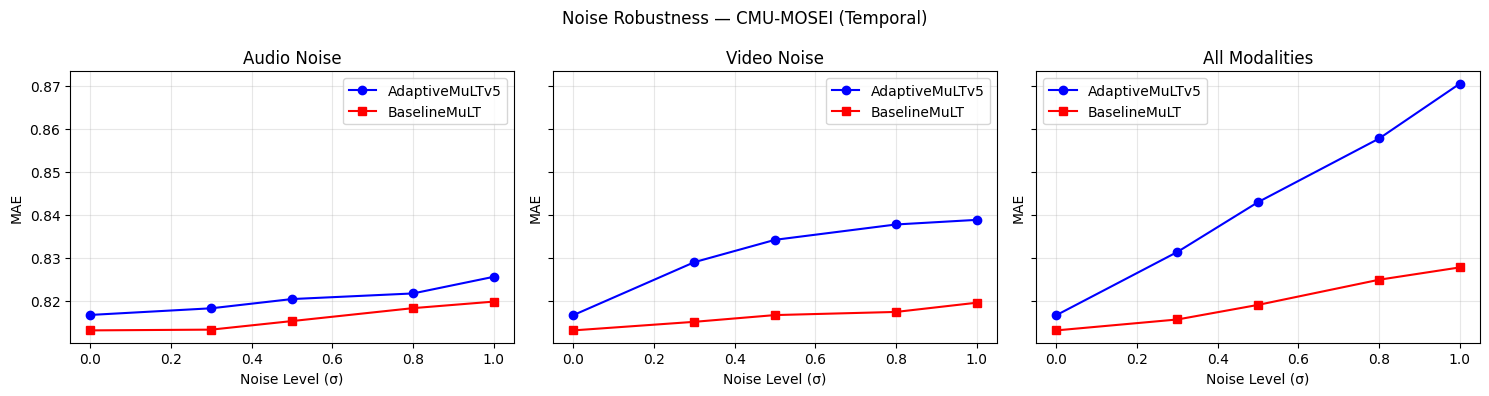

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio    Est. Video     Est. Text
   0.0        0.0227        0.9761        0.0425
   0.3        0.1155        0.9763        0.1724
   0.5        0.4098        0.9757        0.1844
   0.8        0.6128        0.9753        0.1909
   1.0        0.6574        0.9752        0.1931


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

RERUN 2

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
      mean = x.mean(dim=1)
      std  = x.std(dim=1, unbiased=False)
      std  = torch.nan_to_num(std, nan=0.0)
      # Normalise std by mean std across batch to remove modality-specific scale
      std  = std / (std.mean(dim=-1, keepdim=True) + 1e-8)
      return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 40
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/40 | τ=0.800 | noise=[0.12,1.20] | LR=4.65e-05 | Loss A=1.2734 B=1.4526 | ValMAE A=0.7780 B=0.7781 | Best A=0.7780 B=0.7781 | NestErr=0.2321 | NoImprove=0
Epoch   5/40 | τ=0.723 | noise=[0.11,1.09] | LR=1.94e-05 | Loss A=1.2665 B=1.4474 | ValMAE A=0.7778 B=0.7778 | Best A=0.7778 B=0.7778 | NestErr=0.0752 | NoImprove=0
Epoch  10/40 | τ=0.627 | noise=[0.09,0.95] | LR=5.00e-07 | Loss A=1.2063 B=1.4088 | ValMAE A=0.7520 B=0.7684 | Best A=0.7520 B=0.7684 | NestErr=0.0323 | NoImprove=0
Epoch  15/40 | τ=0.531 | noise=[0.08,0.81] | LR=1.94e-05 | Loss A=1.1923 B=1.3674 | ValMAE A=0.7580 B=0.7640 | Best A=0.7520 B=0.7617 | NestErr=0.0204 | NoImprove=2
Epoch  20/40 | τ=0.435 | noise=[0.07,0.66] | LR=4.75e-05 | Loss A=1.1613 B=1.3271 | ValMAE A=0.7680 B=0.7712 | Best A=0.7520 B=0.7617 | NestErr=0.0160 | NoImprove=7
Epoch  25/40 | τ=0.338 | noise=[0.05,0.52] | LR=4.06e-05 | Loss A=1.1358 B=1.3047 | ValMAE A=0.7706 B=0

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

improving noise estimator

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

        # Per-modality running statistics for normalisation
        self.register_buffer('audio_std_mean', torch.ones(1))
        self.register_buffer('video_std_mean', torch.ones(1))
        self.register_buffer('text_std_mean',  torch.ones(1))
        self.register_buffer('ema_decay', torch.tensor(0.99))

    def pool(self, x, std_mean_buf):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        # Normalise by running mean of std across feature dim
        std_normalised = std / (std_mean_buf + 1e-8)
        return torch.cat([mean, std_normalised], dim=-1)

    def update_running_stats(self, x, buf):
        with torch.no_grad():
            current = x.std(dim=1, unbiased=False).mean()
            current = torch.nan_to_num(current, nan=0.0)
            buf.copy_(self.ema_decay * buf + (1 - self.ema_decay) * current)

    def forward(self, a, v, t):
        if self.training:
            self.update_running_stats(a, self.audio_std_mean)
            self.update_running_stats(v, self.video_std_mean)
            self.update_running_stats(t, self.text_std_mean)

        return (self.audio_est(self.pool(a, self.audio_std_mean)).squeeze(-1),
                self.video_est(self.pool(v, self.video_std_mean)).squeeze(-1),
                self.text_est(self.pool(t, self.text_std_mean)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 40
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

        sched_a.step()
        sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/40 | τ=0.800 | noise=[0.12,1.20] | LR=4.65e-05 | Loss A=1.2697 B=1.4518 | ValMAE A=0.7778 B=0.7779 | Best A=0.7778 B=0.7779 | NestErr=0.2454 | NoImprove=0
Epoch   5/40 | τ=0.723 | noise=[0.11,1.09] | LR=1.94e-05 | Loss A=1.2665 B=1.4487 | ValMAE A=0.7780 B=0.7781 | Best A=0.7778 B=0.7779 | NestErr=0.0725 | NoImprove=4
Epoch  10/40 | τ=0.627 | noise=[0.09,0.95] | LR=5.00e-07 | Loss A=1.2538 B=1.4091 | ValMAE A=0.7514 B=0.7739 | Best A=0.7514 B=0.7680 | NestErr=0.0303 | NoImprove=0
Epoch  15/40 | τ=0.531 | noise=[0.08,0.81] | LR=1.94e-05 | Loss A=1.1791 B=1.3571 | ValMAE A=0.7700 B=0.7780 | Best A=0.7514 B=0.7618 | NestErr=0.0188 | NoImprove=3
Epoch  20/40 | τ=0.435 | noise=[0.07,0.66] | LR=4.75e-05 | Loss A=1.1502 B=1.3323 | ValMAE A=0.7772 B=0.7667 | Best A=0.7514 B=0.7611 | NestErr=0.0157 | NoImprove=4
Epoch  25/40 | τ=0.338 | noise=[0.05,0.52] | LR=4.06e-05 | Loss A=1.1270 B=1.3141 | ValMAE A=0.7881 B=0

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8153  Corr=0.2049  Acc2=0.5950
Baseline  MAE=0.8123  Corr=0.2808  Acc2=0.6905

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8153         0.8123     -0.0030
   0.3         0.8153         0.8173      0.0020
   0.5         0.8154         0.8233      0.0079
   0.8         0.8156         0.8315      0.0160
   1.0         0.8156         0.8349      0.0193

── Video Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8153         0.8123     -0.0030
   0.3         0.8286         0.8408      0.0122
   0.5         0.8378         0.8536      0.0158
   0.8         0.8400         0.8668      0.0268
   1.0         0.8404         0.8731      0.0327

── All Modalities Noise Robustness ─────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8153         0.8123     -0.0030
   0.3         0.8315

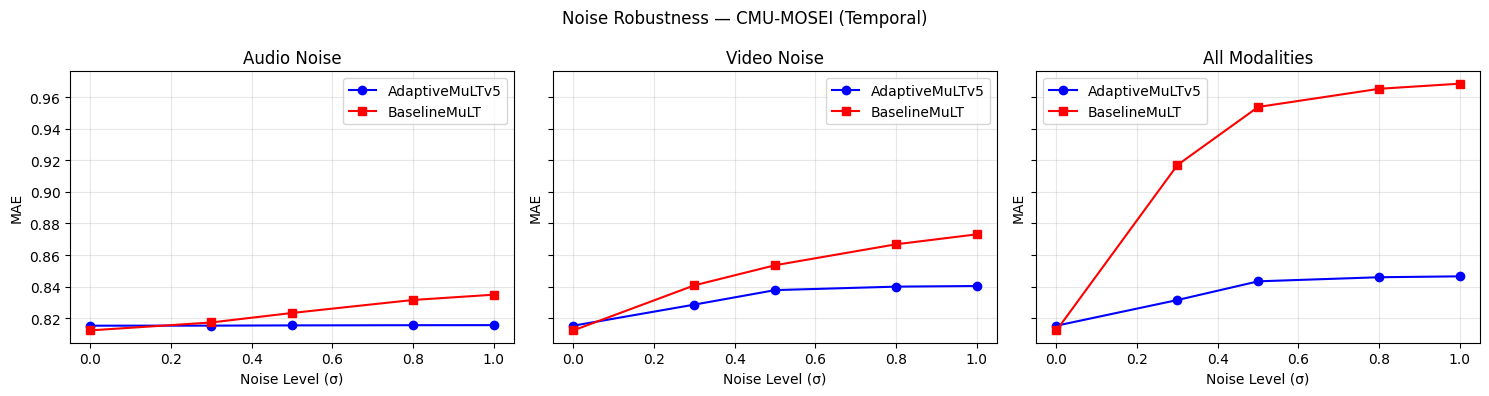

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio    Est. Video     Est. Text
   0.0        0.0188        0.0407        0.0363
   0.3        0.2651        0.0498        0.2092
   0.5        0.4696        0.0560        0.2232
   0.8        0.7027        0.0609        0.2310
   1.0        0.7996        0.0628        0.2344


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

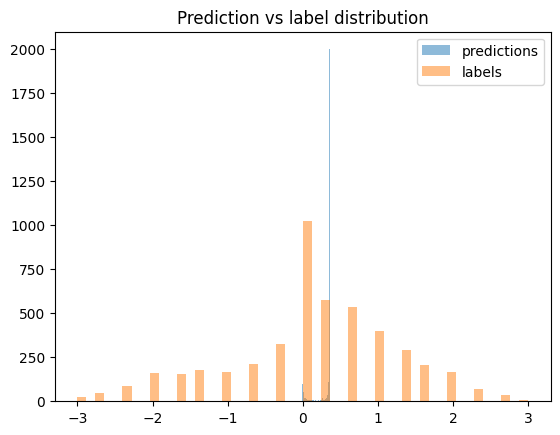

Pred mean: 0.175  std: 0.177
Label mean: 0.142  std: 1.109


In [ ]:
preds, labels_all = [], []
with torch.no_grad():
    for audio, video, text, labels in test_loader:
        audio, video, text = audio.to(device), video.to(device), text.to(device)
        out = adaptive_model(audio, video, text, tau=0.05)[0]
        preds.append(out.cpu())
        labels_all.append(labels)
preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()
import matplotlib.pyplot as plt
plt.hist(preds, bins=50, alpha=0.5, label='predictions')
plt.hist(labels_all, bins=50, alpha=0.5, label='labels')
plt.legend()
plt.title('Prediction vs label distribution')
plt.show()
print(f"Pred mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Label mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

        self.register_buffer('audio_std_mean', torch.ones(1))
        self.register_buffer('video_std_mean', torch.ones(1))
        self.register_buffer('text_std_mean',  torch.ones(1))
        self.ema_decay = 0.999  # slower update than before

    def pool(self, x, std_mean_buf):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        # stop-gradient on normalisation so it does not interfere with task loss
        std_normalised = std / (std_mean_buf.detach() + 1e-8)
        return torch.cat([mean, std_normalised], dim=-1)

    def update_running_stats(self, x, buf):
        with torch.no_grad():
            current = x.std(dim=1, unbiased=False).mean()
            current = torch.nan_to_num(current, nan=0.0)
            buf.copy_(self.ema_decay * buf + (1 - self.ema_decay) * current)

    def forward(self, a, v, t):
        if self.training:
            self.update_running_stats(a, self.audio_std_mean)
            self.update_running_stats(v, self.video_std_mean)
            self.update_running_stats(t, self.text_std_mean)

        return (self.audio_est(self.pool(a, self.audio_std_mean)).squeeze(-1),
                self.video_est(self.pool(v, self.video_std_mean)).squeeze(-1),
                self.text_est(self.pool(t, self.text_std_mean)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.00e-05 | Loss A=1.2707 B=1.4562 | ValMAE A=0.7782 B=0.7781 | Best A=0.7782 B=0.7781 | NestErr=0.2986 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.2677 B=1.4498 | ValMAE A=0.7781 B=0.7778 | Best A=0.7778 B=0.7778 | NestErr=0.0974 | NoImprove=0
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.1966 B=1.3621 | ValMAE A=0.7588 B=0.7695 | Best A=0.7525 B=0.7604 | NestErr=0.0472 | NoImprove=2
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.1626 B=1.3126 | ValMAE A=0.7639 B=0.7652 | Best A=0.7525 B=0.7599 | NestErr=0.0311 | NoImprove=2
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.1182 B=1.2795 | ValMAE A=0.7817 B=0.7759 | Best A=0.7525 B=0.7599 | NestErr=0.0244 | NoImprove=7
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0908 B=1.2627 | ValMAE A=0.7726 B=0

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8088  Corr=0.2227  Acc2=0.7102
Baseline  MAE=0.8070  Corr=0.3046  Acc2=0.7115

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8088         0.8070     -0.0017
   0.3         0.8063         0.8724      0.0661
   0.5         0.8062         0.9108      0.1046
   0.8         0.8065         0.9285      0.1220
   1.0         0.8067         0.9360      0.1292

── Video Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8088         0.8070     -0.0017
   0.3         0.8222         0.8264      0.0042
   0.5         0.8371         0.8333     -0.0038
   0.8         0.8499         0.8381     -0.0118
   1.0         0.8555         0.8413     -0.0142

── All Modalities Noise Robustness ─────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8088         0.8070     -0.0017
   0.3         0.8180

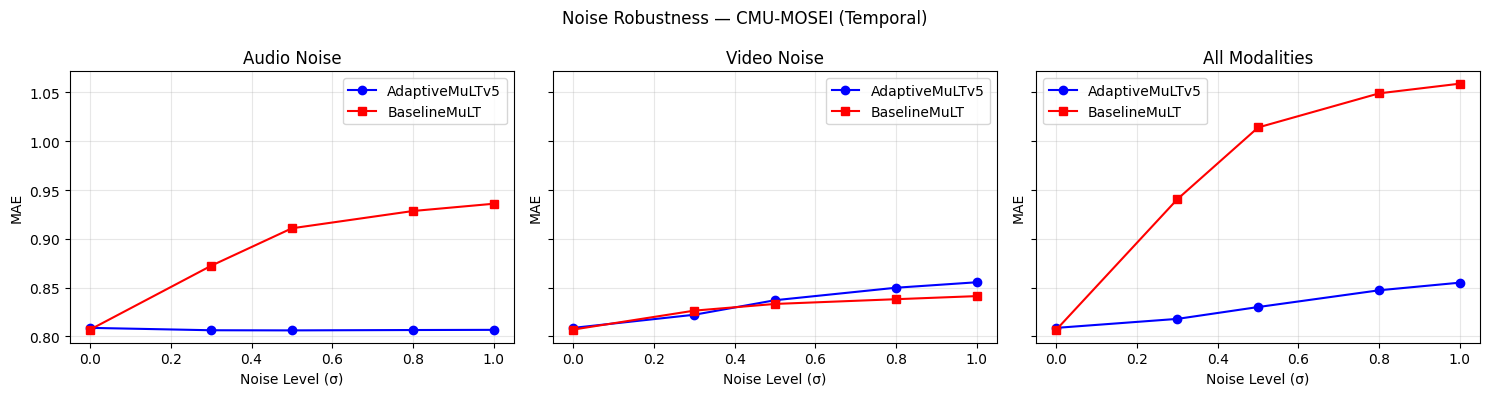

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio    Est. Video     Est. Text
   0.0        0.0139        0.9944        0.9976
   0.3        0.2147        0.9907        0.9262
   0.5        0.4599        0.9889        0.9147
   0.8        0.7045        0.9874        0.9063
   1.0        0.8058        0.9868        0.9042


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

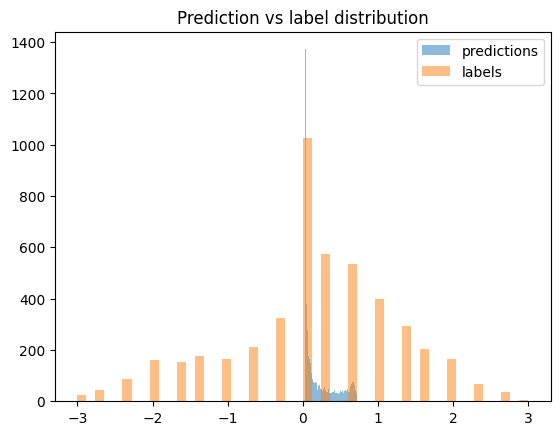

Pred mean: 0.201  std: 0.214
Label mean: 0.142  std: 1.109


In [ ]:
preds, labels_all = [], []
with torch.no_grad():
    for audio, video, text, labels in test_loader:
        audio, video, text = audio.to(device), video.to(device), text.to(device)
        out = adaptive_model(audio, video, text, tau=0.05)[0]
        preds.append(out.cpu())
        labels_all.append(labels)
preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()
import matplotlib.pyplot as plt
plt.hist(preds, bins=50, alpha=0.5, label='predictions')
plt.hist(labels_all, bins=50, alpha=0.5, label='labels')
plt.legend()
plt.title('Prediction vs label distribution')
plt.show()
print(f"Pred mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Label mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")

rerun again

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l = sign_loss(pred_c, labels)

            # ── Audio noise ───────────────────────────────────────────────────
            nl_a = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_a.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_na, na_n, nv_na, nt_na, g_na = adaptive_model(n_audio, video, text, tau=tau)
            noisy_task_a = safe_loss(mse(pred_na, labels), "noisy_task_a") or \
                           torch.tensor(0.0, device=device)

            # ── Video noise ───────────────────────────────────────────────────
            nl_v = torch.rand(video.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_video = torch.nan_to_num(
                video + torch.randn_like(video) * nl_v.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nv, na_nv, nv_n, nt_nv, g_nv = adaptive_model(audio, n_video, text, tau=tau)
            noisy_task_v = safe_loss(mse(pred_nv, labels), "noisy_task_v") or \
                           torch.tensor(0.0, device=device)

            # ── All modalities noise ──────────────────────────────────────────
            nl_all = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio_all = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            n_video_all = torch.nan_to_num(
                video + torch.randn_like(video) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nall, na_nall, nv_nall, nt_nall, g_nall = adaptive_model(
                n_audio_all, n_video_all, text, tau=tau)
            noisy_task_all = safe_loss(mse(pred_nall, labels), "noisy_task_all") or \
                             torch.tensor(0.0, device=device)

            # ── Noise supervision ─────────────────────────────────────────────
            n_clean_a    = mse(na_c,  torch.zeros(audio.size(0), device=device))
            n_clean_v    = mse(nv_c,  torch.zeros(audio.size(0), device=device))
            n_noisy_a    = mse(na_n,  nl_a)
            n_noisy_v    = mse(nv_n,  nl_v)
            noise_sup    = (n_clean_a + n_noisy_a + n_clean_v + n_noisy_v) / 4

            # ── Entropy ───────────────────────────────────────────────────────
            ent = entropy_loss(g_c)

            # ── Contrastive gate loss — audio, video, all ─────────────────────
            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_na[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nv[:,1:2,:])
            contrast_all = (
                contrastive_gate_loss(g_c[:,0:1,:].detach(), g_nall[:,0:1,:]) +
                contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nall[:,1:2,:]) +
                contrastive_gate_loss(g_c[:,2:3,:].detach(), g_nall[:,2:3,:])
            ) / 3
            contrast = (contrast_a + contrast_v + contrast_all) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl_a).abs().mean().item())

            noisy_task = (noisy_task_a + noisy_task_v + noisy_task_all) / 3

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda


NameError: name 'AdaptiveMuLTv5' is not defined

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        def _conv_est():
            return nn.Sequential(
                # Local temporal patterns — noise creates high-freq perturbations
                nn.Conv1d(d_model, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(64, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),   # global pool → (B, 32, 1)
            )

        def _mlp_head():
            return nn.Sequential(
                nn.Linear(32 + d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid(),
            )

        # Separate conv + mlp per modality
        self.audio_conv = _conv_est()
        self.video_conv = _conv_est()
        self.text_conv  = _conv_est()

        self.audio_mlp  = _mlp_head()
        self.video_mlp  = _mlp_head()
        self.text_mlp   = _mlp_head()

        # Per-modality learned scale and shift for variance normalisation
        self.audio_norm = nn.LayerNorm(d_model)
        self.video_norm = nn.LayerNorm(d_model)
        self.text_norm  = nn.LayerNorm(d_model)

    def pool_stats(self, x, norm):
        # Normalise first to remove modality-specific scale
        x_norm = norm(x)
        mean = x_norm.mean(dim=1)
        std  = x_norm.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return mean, std, x_norm

    def forward_one(self, x, norm, conv, mlp):
        mean, std, x_norm = self.pool_stats(x, norm)
        # Conv over temporal dim — expects (B, C, T)
        conv_feat = conv(x_norm.transpose(1, 2)).squeeze(-1)  # (B, 32)
        combined  = torch.cat([mean, std, conv_feat], dim=-1)  # (B, d*2 + 32)
        return mlp(combined).squeeze(-1)

    def forward(self, a, v, t):
        return (
            self.forward_one(a, self.audio_norm, self.audio_conv, self.audio_mlp),
            self.forward_one(v, self.video_norm, self.video_conv, self.video_mlp),
            self.forward_one(t, self.text_norm,  self.text_conv,  self.text_mlp),
        )

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,730,992
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,730,992
Baseline params: 1,355,265
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.00e-05 | Loss A=1.2722 B=1.4525 | ValMAE A=0.7778 B=0.7780 | Best A=0.7778 B=0.7780 | NestErr=0.2170 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.2675 B=1.4498 | ValMAE A=0.7780 B=0.7781 | Best A=0.7777 B=0.7777 | NestErr=0.0493 | NoImprove=1
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.2032 B=1.3692 | ValMAE A=0.7577 B=0.7599 | Best A=0.7533 B=0.7589 | NestErr=0.0204 | NoImprove=1
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.1639 B=1.3223 | ValMAE A=0.7679 B=0.7718 | Best A=0.7533 B=0.7589 | NestErr=0.0197 | NoImprove=6
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.1274 B=1.2943 | ValMAE A=0.7608 B=0.7651 | Best A=0.7533 B=0.7589 | NestErr=0.0189 | NoImprove=11
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0875 B=1.2602 | ValMAE A=0.7635 B=

── Clean Test ──────────────────────────────────
Adaptive  MAE=0.8106  Corr=0.2244  Acc2=0.7102
Baseline  MAE=0.8142  Corr=0.2572  Acc2=0.6980

── Audio Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8106         0.8142      0.0035
   0.3         0.8096         0.8146      0.0050
   0.5         0.8094         0.8135      0.0041
   0.8         0.8094         0.8124      0.0030
   1.0         0.8094         0.8146      0.0053

── Video Noise Robustness ──────────────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8106         0.8142      0.0035
   0.3         0.8361         0.8265     -0.0096
   0.5         0.8673         0.8316     -0.0356
   0.8         0.8975         0.8337     -0.0638
   1.0         0.9039         0.8346     -0.0694

── All Modalities Noise Robustness ─────────────
 Noise   Adaptive MAE   Baseline MAE     Δ (B-A)
   0.0         0.8106         0.8142      0.0035
   0.3         0.8315

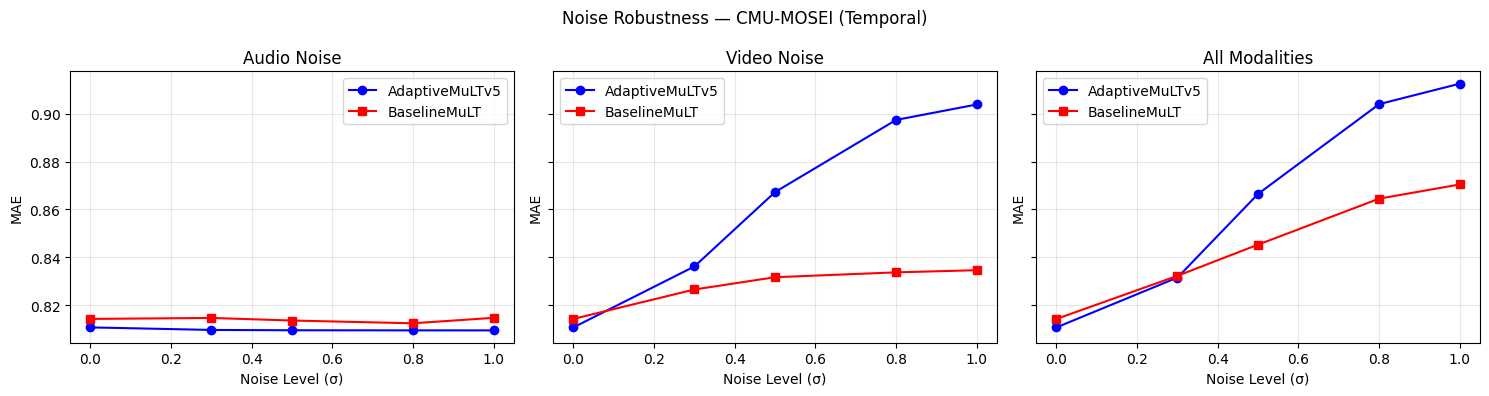

Plot saved.

── Noise Estimator Calibration ─────────────────
 Noise    Est. Audio    Est. Video     Est. Text
   0.0        0.0003        0.6918        0.9835
   0.3        0.2631        0.6855        0.9736
   0.5        0.4377        0.6736        0.9718
   0.8        0.7830        0.6645        0.9705
   1.0        0.9760        0.6613        0.9701


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

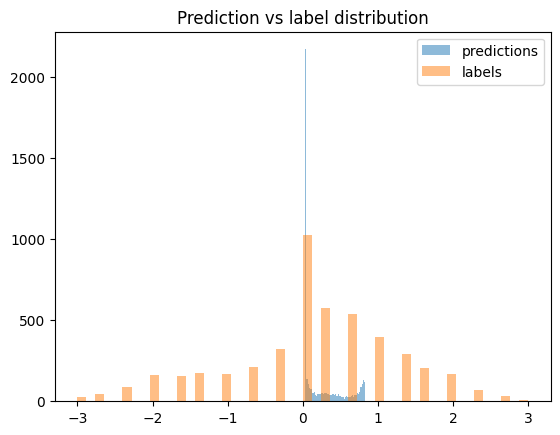

Pred mean: 0.243  std: 0.276
Label mean: 0.142  std: 1.109


In [ ]:
preds, labels_all = [], []
with torch.no_grad():
    for audio, video, text, labels in test_loader:
        audio, video, text = audio.to(device), video.to(device), text.to(device)
        out = adaptive_model(audio, video, text, tau=0.05)[0]
        preds.append(out.cpu())
        labels_all.append(labels)
preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()
import matplotlib.pyplot as plt
plt.hist(preds, bins=50, alpha=0.5, label='predictions')
plt.hist(labels_all, bins=50, alpha=0.5, label='labels')
plt.legend()
plt.title('Prediction vs label distribution')
plt.show()
print(f"Pred mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Label mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")

rerun again

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l = sign_loss(pred_c, labels)

            # ── Audio noise ───────────────────────────────────────────────────
            nl_a = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_a.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_na, na_n, nv_na, nt_na, g_na = adaptive_model(n_audio, video, text, tau=tau)
            noisy_task_a = safe_loss(mse(pred_na, labels), "noisy_task_a") or \
                           torch.tensor(0.0, device=device)

            # ── Video noise ───────────────────────────────────────────────────
            nl_v = torch.rand(video.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_video = torch.nan_to_num(
                video + torch.randn_like(video) * nl_v.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nv, na_nv, nv_n, nt_nv, g_nv = adaptive_model(audio, n_video, text, tau=tau)
            noisy_task_v = safe_loss(mse(pred_nv, labels), "noisy_task_v") or \
                           torch.tensor(0.0, device=device)

            # ── All modalities noise ──────────────────────────────────────────
            nl_all = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio_all = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            n_video_all = torch.nan_to_num(
                video + torch.randn_like(video) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nall, na_nall, nv_nall, nt_nall, g_nall = adaptive_model(
                n_audio_all, n_video_all, text, tau=tau)
            noisy_task_all = safe_loss(mse(pred_nall, labels), "noisy_task_all") or \
                             torch.tensor(0.0, device=device)

            # ── Noise supervision ─────────────────────────────────────────────
            n_clean_a    = mse(na_c,  torch.zeros(audio.size(0), device=device))
            n_clean_v    = mse(nv_c,  torch.zeros(audio.size(0), device=device))
            n_noisy_a    = mse(na_n,  nl_a)
            n_noisy_v    = mse(nv_n,  nl_v)
            noise_sup    = (n_clean_a + n_noisy_a + n_clean_v + n_noisy_v) / 4

            # ── Entropy ───────────────────────────────────────────────────────
            ent = entropy_loss(g_c)

            # ── Contrastive gate loss — audio, video, all ─────────────────────
            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_na[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nv[:,1:2,:])
            contrast_all = (
                contrastive_gate_loss(g_c[:,0:1,:].detach(), g_nall[:,0:1,:]) +
                contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nall[:,1:2,:]) +
                contrastive_gate_loss(g_c[:,2:3,:].detach(), g_nall[:,2:3,:])
            ) / 3
            contrast = (contrast_a + contrast_v + contrast_all) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl_a).abs().mean().item())

            noisy_task = (noisy_task_a + noisy_task_v + noisy_task_all) / 3

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265
Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.00e-05 | Loss A=1.2687 B=1.4482 | ValMAE A=0.7786 B=0.7781 | Best A=0.7786 B=0.7781 | NestErr=0.2912 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.2674 B=1.4488 | ValMAE A=0.7778 B=0.7778 | Best A=0.7777 B=0.7777 | NestErr=0.0739 | NoImprove=2
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.1994 B=1.3630 | ValMAE A=0.7517 B=0.7657 | Best A=0.7517 B=0.7657 | NestErr=0.0317 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.1329 B=1.3153 | ValMAE A=0.8058 B=0.7665 | Best A=0.7517 B=0.7599 | NestErr=0.0224 | NoImprove=3
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.0990 B=1.2933 | ValMAE A=0.7747 B=0.7888 | Best A=0.7517 B=0.7599 | NestErr=0.0217 | NoImprove=8
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0751 B=1.2666 | ValMAE A=0.7608 B=0

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
preds, labels_all = [], []
with torch.no_grad():
    for audio, video, text, labels in test_loader:
        audio, video, text = audio.to(device), video.to(device), text.to(device)
        out = adaptive_model(audio, video, text, tau=0.05)[0]
        preds.append(out.cpu())
        labels_all.append(labels)
preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()
import matplotlib.pyplot as plt
plt.hist(preds, bins=50, alpha=0.5, label='predictions')
plt.hist(labels_all, bins=50, alpha=0.5, label='labels')
plt.legend()
plt.title('Prediction vs label distribution')
plt.show()
print(f"Pred mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Label mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")

rerun again

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l = sign_loss(pred_c, labels)

            # ── Audio noise ───────────────────────────────────────────────────
            nl_a = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_a.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_na, na_n, nv_na, nt_na, g_na = adaptive_model(n_audio, video, text, tau=tau)
            noisy_task_a = safe_loss(mse(pred_na, labels), "noisy_task_a") or \
                           torch.tensor(0.0, device=device)

            # ── Video noise ───────────────────────────────────────────────────
            nl_v = torch.rand(video.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_video = torch.nan_to_num(
                video + torch.randn_like(video) * nl_v.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nv, na_nv, nv_n, nt_nv, g_nv = adaptive_model(audio, n_video, text, tau=tau)
            noisy_task_v = safe_loss(mse(pred_nv, labels), "noisy_task_v") or \
                           torch.tensor(0.0, device=device)

            # ── All modalities noise ──────────────────────────────────────────
            nl_all = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio_all = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            n_video_all = torch.nan_to_num(
                video + torch.randn_like(video) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nall, na_nall, nv_nall, nt_nall, g_nall = adaptive_model(
                n_audio_all, n_video_all, text, tau=tau)
            noisy_task_all = safe_loss(mse(pred_nall, labels), "noisy_task_all") or \
                             torch.tensor(0.0, device=device)

            # ── Noise supervision ─────────────────────────────────────────────
            n_clean_a    = mse(na_c,  torch.zeros(audio.size(0), device=device))
            n_clean_v    = mse(nv_c,  torch.zeros(audio.size(0), device=device))
            n_noisy_a    = mse(na_n,  nl_a)
            n_noisy_v    = mse(nv_n,  nl_v)
            noise_sup    = (n_clean_a + n_noisy_a + n_clean_v + n_noisy_v) / 4

            # ── Entropy ───────────────────────────────────────────────────────
            ent = entropy_loss(g_c)

            # ── Contrastive gate loss — audio, video, all ─────────────────────
            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_na[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nv[:,1:2,:])
            contrast_all = (
                contrastive_gate_loss(g_c[:,0:1,:].detach(), g_nall[:,0:1,:]) +
                contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nall[:,1:2,:]) +
                contrastive_gate_loss(g_c[:,2:3,:].detach(), g_nall[:,2:3,:])
            ) / 3
            contrast = (contrast_a + contrast_v + contrast_all) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl_a).abs().mean().item())

            noisy_task = (noisy_task_a + noisy_task_v + noisy_task_all) / 3

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

# Verify temporal structure
samples = list(aligned['train'].items())[:3]
for sid, entry in samples:
    print(f"\nID: {sid}")
    print(f"  Audio shape: {entry['audio'].shape}")
    print(f"  Video shape: {entry['video'].shape}")
    print(f"  Label:       {entry['label']:.4f}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852

ID: -3g5yACwYnA[0]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       1.0000

ID: -3g5yACwYnA[1]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.6667

ID: -3g5yACwYnA[2]
  Audio shape: (1, 74)
  Video shape: (1, 35)
  Label:       0.0000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print("Models defined.")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined.
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task = safe_loss(mse(pred_n, labels), "noisy_task")
            if noisy_task is None:
                noisy_task = torch.tensor(0.0, device=device)

            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(
                mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels),
                "base")
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Training on: cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
preds, labels_all = [], []
with torch.no_grad():
    for audio, video, text, labels in test_loader:
        audio, video, text = audio.to(device), video.to(device), text.to(device)
        out = adaptive_model(audio, video, text, tau=0.05)[0]
        preds.append(out.cpu())
        labels_all.append(labels)
preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()
import matplotlib.pyplot as plt
plt.hist(preds, bins=50, alpha=0.5, label='predictions')
plt.hist(labels_all, bins=50, alpha=0.5, label='labels')
plt.legend()
plt.title('Prediction vs label distribution')
plt.show()
print(f"Pred mean: {preds.mean():.3f}  std: {preds.std():.3f}")
print(f"Label mean: {labels_all.mean():.3f}  std: {labels_all.std():.3f}")

rerun again

In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)
print(f"Adaptive params: {sum(p.numel() for p in adaptive_model.parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    pred_sign  = torch.sigmoid(pred * 5.0)
    label_sign = (labels >= 0).float()
    return F.binary_cross_entropy(pred_sign, label_sign)

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels), "task")
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l = sign_loss(pred_c, labels)

            # ── Audio noise ───────────────────────────────────────────────────
            nl_a = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_a.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_na, na_n, nv_na, nt_na, g_na = adaptive_model(n_audio, video, text, tau=tau)
            noisy_task_a = safe_loss(mse(pred_na, labels), "noisy_task_a") or \
                           torch.tensor(0.0, device=device)

            # ── Video noise ───────────────────────────────────────────────────
            nl_v = torch.rand(video.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_video = torch.nan_to_num(
                video + torch.randn_like(video) * nl_v.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nv, na_nv, nv_n, nt_nv, g_nv = adaptive_model(audio, n_video, text, tau=tau)
            noisy_task_v = safe_loss(mse(pred_nv, labels), "noisy_task_v") or \
                           torch.tensor(0.0, device=device)

            # ── All modalities noise ──────────────────────────────────────────
            nl_all = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio_all = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            n_video_all = torch.nan_to_num(
                video + torch.randn_like(video) * nl_all.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)
            pred_nall, na_nall, nv_nall, nt_nall, g_nall = adaptive_model(
                n_audio_all, n_video_all, text, tau=tau)
            noisy_task_all = safe_loss(mse(pred_nall, labels), "noisy_task_all") or \
                             torch.tensor(0.0, device=device)

            # ── Noise supervision ─────────────────────────────────────────────
            n_clean_a    = mse(na_c,  torch.zeros(audio.size(0), device=device))
            n_clean_v    = mse(nv_c,  torch.zeros(audio.size(0), device=device))
            n_noisy_a    = mse(na_n,  nl_a)
            n_noisy_v    = mse(nv_n,  nl_v)
            noise_sup    = (n_clean_a + n_noisy_a + n_clean_v + n_noisy_v) / 4

            # ── Entropy ───────────────────────────────────────────────────────
            ent = entropy_loss(g_c)

            # ── Contrastive gate loss — audio, video, all ─────────────────────
            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_na[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nv[:,1:2,:])
            contrast_all = (
                contrastive_gate_loss(g_c[:,0:1,:].detach(), g_nall[:,0:1,:]) +
                contrastive_gate_loss(g_c[:,1:2,:].detach(), g_nall[:,1:2,:]) +
                contrastive_gate_loss(g_c[:,2:3,:].detach(), g_nall[:,2:3,:])
            ) / 3
            contrast = (contrast_a + contrast_v + contrast_all) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl_a).abs().mean().item())

            noisy_task = (noisy_task_a + noisy_task_v + noisy_task_all) / 3

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a, "total")
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

    # ── Step schedulers once per epoch after all batches ──────────────────────
    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_temporal.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_temporal.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.load_state_dict(torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
baseline_model.load_state_dict(torch.load(CSD_DIR + 'best_baseline_temporal.pt', map_location=device))
adaptive_model.eval()
baseline_model.eval()

def evaluate(model, loader, is_adaptive=True, tau=0.05):
    preds, labels_all = [], []
    with torch.no_grad():
        for audio, video, text, labels in loader:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            out = model(audio, video, text, tau=tau)[0] if is_adaptive \
                  else model(audio, video, text)
            preds.append(torch.nan_to_num(out, nan=0.0).cpu())
            labels_all.append(labels)
    preds      = torch.cat(preds)
    labels_all = torch.cat(labels_all)
    mae  = (preds - labels_all).abs().mean().item()
    corr = np.corrcoef(preds.numpy(), labels_all.numpy())[0, 1]
    acc2 = ((preds >= 0) == (labels_all >= 0)).float().mean().item()
    return mae, corr, acc2

mae_a, corr_a, acc_a = evaluate(adaptive_model, test_loader, is_adaptive=True)
mae_b, corr_b, acc_b = evaluate(baseline_model, test_loader, is_adaptive=False)
print("── Clean Test ──────────────────────────────────")
print(f"Adaptive  MAE={mae_a:.4f}  Corr={corr_a:.4f}  Acc2={acc_a:.4f}")
print(f"Baseline  MAE={mae_b:.4f}  Corr={corr_b:.4f}  Acc2={acc_b:.4f}")

noise_levels = [0.0, 0.3, 0.5, 0.8, 1.0]

# ── Audio noise ───────────────────────────────────────────────────────────────
results = {'adaptive': [], 'baseline': []}
print("\n── Audio Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='audio')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results['adaptive'].append(ma)
    results['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Video noise ───────────────────────────────────────────────────────────────
results_v = {'adaptive': [], 'baseline': []}
print("\n── Video Noise Robustness ──────────────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='video')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_v['adaptive'].append(ma)
    results_v['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── All modalities noise ──────────────────────────────────────────────────────
results_all = {'adaptive': [], 'baseline': []}
print("\n── All Modalities Noise Robustness ─────────────")
print(f"{'Noise':>6}  {'Adaptive MAE':>13}  {'Baseline MAE':>13}  {'Δ (B-A)':>10}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    ma, *_ = evaluate(adaptive_model, ldr, is_adaptive=True)
    mb, *_ = evaluate(baseline_model, ldr, is_adaptive=False)
    results_all['adaptive'].append(ma)
    results_all['baseline'].append(mb)
    print(f"{nl:>6.1f}  {ma:>13.4f}  {mb:>13.4f}  {mb-ma:>10.4f}")

# ── Combined plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, res, title in zip(
        axes,
        [results, results_v, results_all],
        ['Audio Noise', 'Video Noise', 'All Modalities']):
    ax.plot(noise_levels, res['adaptive'], 'b-o', label='AdaptiveMuLTv5')
    ax.plot(noise_levels, res['baseline'], 'r-s', label='BaselineMuLT')
    ax.set_title(title)
    ax.set_xlabel('Noise Level (σ)')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Robustness — CMU-MOSEI (Temporal)')
plt.tight_layout()
plt.savefig(CSD_DIR + 'noise_robustness_temporal.png', dpi=150)
plt.show()
print("Plot saved.")

# ── Noise estimator calibration ───────────────────────────────────────────────
print("\n── Noise Estimator Calibration ─────────────────")
print(f"{'Noise':>6}  {'Est. Audio':>12}  {'Est. Video':>12}  {'Est. Text':>12}")
for nl in noise_levels:
    ds  = MOSEIDataset(aligned['test'], bert_cache, noise_level=nl, noise_modality='all')
    ldr = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    est_a, est_v, est_t = [], [], []
    with torch.no_grad():
        for audio, video, text, _ in ldr:
            audio, video, text = audio.to(device), video.to(device), text.to(device)
            _, na, nv, nt, _ = adaptive_model(audio, video, text, tau=0.05)
            est_a.append(na.cpu().mean().item())
            est_v.append(nv.cpu().mean().item())
            est_t.append(nt.cpu().mean().item())
    print(f"{nl:>6.1f}  {np.mean(est_a):>12.4f}  "
          f"{np.mean(est_v):>12.4f}  {np.mean(est_t):>12.4f}")

In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")
print(f"BERT cache entries: {len(bert_cache)}")

Train: 16322  Valid: 1871  Test: 4659
BERT cache entries: 22852


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

    def pool(self, x):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        return torch.cat([mean, std], dim=-1)

    def forward(self, a, v, t):
        return (self.audio_est(self.pool(a)).squeeze(-1),
                self.video_est(self.pool(v)).squeeze(-1),
                self.text_est(self.pool(t)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

print(f"Models defined on {device}")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")

Models defined on cuda
Adaptive params: 7,631,632


In [ ]:
import numpy as np

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

print(f"MAX_A={MAX_A}  MAX_V={MAX_V}")

MAX_A=500  MAX_V=500


In [ ]:
adaptive_model = AdaptiveMuLTv5().to(device)
adaptive_model.load_state_dict(torch.load(
    CSD_DIR + 'best_adaptive_temporal.pt', map_location=device))
adaptive_model.eval()
print("Checkpoint loaded.")

Checkpoint loaded.


In [ ]:
state = torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location='cpu')
print("Noise estimator keys:")
for k in state.keys():
    if 'noise' in k:
        print(f"  {k}: {state[k].shape}")

Noise estimator keys:
  noise_est.audio_est.0.weight: torch.Size([64, 256])
  noise_est.audio_est.0.bias: torch.Size([64])
  noise_est.audio_est.3.weight: torch.Size([1, 64])
  noise_est.audio_est.3.bias: torch.Size([1])
  noise_est.video_est.0.weight: torch.Size([64, 256])
  noise_est.video_est.0.bias: torch.Size([64])
  noise_est.video_est.3.weight: torch.Size([1, 64])
  noise_est.video_est.3.bias: torch.Size([1])
  noise_est.text_est.0.weight: torch.Size([64, 256])
  noise_est.text_est.0.bias: torch.Size([64])
  noise_est.text_est.3.weight: torch.Size([1, 64])
  noise_est.text_est.3.bias: torch.Size([1])


Ordered samples:
  positive: label=1.33  sid=-9y-fZ3swSY[1]
  negative: label=-2.00  sid=-s9qJ7ATP7w[5]
  neutral: label=0.00  sid=-6rXp3zJ3kc[0]


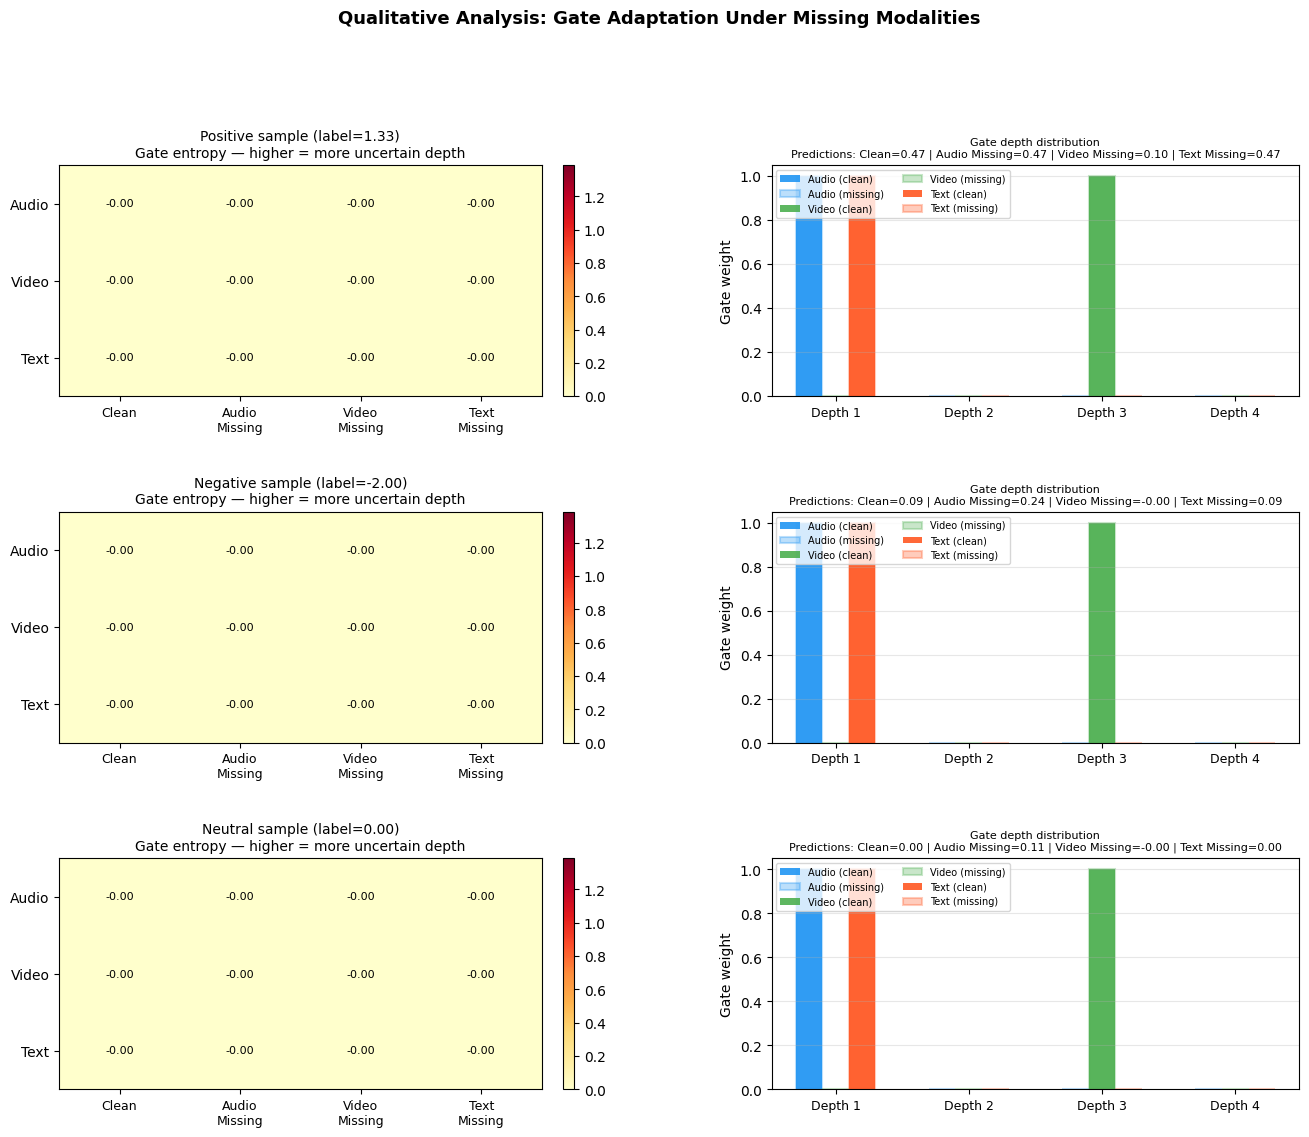

Saved to qualitative_gate_analysis.png

── Prediction Recovery Under Missing Modalities ────────────────────
Sample        Label    Clean   No Audio   No Video    No Text
------------------------------------------------------------
positive       1.33    0.467      0.469      0.099      0.467
negative      -2.00    0.089      0.237     -0.000      0.089
neutral        0.00    0.004      0.105     -0.000      0.004


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.eval()

def get_gates_and_pred(audio, video, text, tau=0.05):
    with torch.no_grad():
        pred, na, nv, nt, gates = adaptive_model(audio, video, text, tau=tau)
    return pred.cpu().numpy(), gates.cpu().numpy()

def get_sample(idx):
    sid, entry = list(aligned['test'].items())[idx]
    audio = torch.from_numpy(
        pad_or_trunc(clean(entry['audio']), MAX_A)).unsqueeze(0).to(device)
    video = torch.from_numpy(
        pad_or_trunc(clean(entry['video']), MAX_V)).unsqueeze(0).to(device)
    text  = torch.from_numpy(
        clean(bert_cache.get(sid, np.zeros(768, dtype=np.float32))).reshape(1, -1)
    ).unsqueeze(0).to(device)
    label = float(entry['label'])
    return audio, video, text, label, sid

# ── Pick samples ──────────────────────────────────────────────────────────────
sample_indices = []
for i, (sid, entry) in enumerate(list(aligned['test'].items())[:2000]):
    label = float(entry['label'])
    if label > 1.0 and not any(s == 'positive' for s, _ in sample_indices):
        sample_indices.append(('positive', i))
    if label < -1.0 and not any(s == 'negative' for s, _ in sample_indices):
        sample_indices.append(('negative', i))
    if abs(label) < 0.1 and not any(s == 'neutral' for s, _ in sample_indices):
        sample_indices.append(('neutral', i))
    if len(sample_indices) == 3:
        break

# Reorder positive, negative, neutral
sample_indices_ordered = []
for target in ['positive', 'negative', 'neutral']:
    for sentiment, idx in sample_indices:
        if sentiment == target:
            sample_indices_ordered.append((sentiment, idx))
            break
sample_indices = sample_indices_ordered

print("Ordered samples:")
for sentiment, idx in sample_indices:
    _, _, _, label, sid = get_sample(idx)
    print(f"  {sentiment}: label={label:.2f}  sid={sid}")

modality_names   = ['Audio', 'Video', 'Text']
condition_labels = ['Clean', 'Audio\nMissing', 'Video\nMissing', 'Text\nMissing']
colors           = ['#2196F3', '#4CAF50', '#FF5722']

fig = plt.figure(figsize=(16, 4 * len(sample_indices)))
gs  = gridspec.GridSpec(len(sample_indices), 2, figure=fig,
                        wspace=0.35, hspace=0.5)

for row, (sentiment, idx) in enumerate(sample_indices):
    audio, video, text, label, sid = get_sample(idx)
    zero_a = torch.zeros_like(audio)
    zero_v = torch.zeros_like(video)
    zero_t = torch.zeros_like(text)

    conditions = [
        ('Clean',         audio,  video,  text),
        ('Audio Missing', zero_a, video,  text),
        ('Video Missing', audio,  zero_v, text),
        ('Text Missing',  audio,  video,  zero_t),
    ]

    all_gates = []
    all_preds = []
    for name, a, v, t in conditions:
        pred, gates = get_gates_and_pred(a, v, t)
        all_gates.append(gates[0])
        all_preds.append(pred[0])

    # ── Left plot: gate entropy heatmap ───────────────────────────────────────
    ax_gates = fig.add_subplot(gs[row, 0])
    gate_matrix  = np.array(all_gates)  # (4, 3, K)
    gate_entropy = -(gate_matrix * np.log(gate_matrix + 1e-8)).sum(axis=-1)  # (4, 3)

    im = ax_gates.imshow(gate_entropy.T, aspect='auto', cmap='YlOrRd',
                         vmin=0, vmax=np.log(K))
    ax_gates.set_xticks(range(4))
    ax_gates.set_xticklabels(condition_labels, fontsize=9)
    ax_gates.set_yticks(range(3))
    ax_gates.set_yticklabels(modality_names, fontsize=10)
    ax_gates.set_title(f'{sentiment.capitalize()} sample (label={label:.2f})\n'
                       f'Gate entropy — higher = more uncertain depth',
                       fontsize=10)
    plt.colorbar(im, ax=ax_gates, fraction=0.046, pad=0.04)

    for ci in range(4):
        for mi in range(3):
            ax_gates.text(ci, mi, f'{gate_entropy[ci, mi]:.2f}',
                         ha='center', va='center', fontsize=8,
                         color='black' if gate_entropy[ci, mi] < 0.7 else 'white')

    # ── Right plot: gate depth distribution ───────────────────────────────────
    ax_depth = fig.add_subplot(gs[row, 1])
    x     = np.arange(K)
    width = 0.2
    for m_idx, (m_name, color) in enumerate(zip(modality_names, colors)):
        clean_weights   = all_gates[0][m_idx]
        missing_weights = all_gates[m_idx + 1][m_idx]
        ax_depth.bar(x + m_idx * width, clean_weights,
                     width, alpha=0.9, color=color,
                     label=f'{m_name} (clean)')
        ax_depth.bar(x + m_idx * width, missing_weights,
                     width, alpha=0.3, color=color,
                     edgecolor=color, linewidth=1.5,
                     label=f'{m_name} (missing)')

    ax_depth.set_xticks(x + width)
    ax_depth.set_xticklabels([f'Depth {k+1}' for k in range(K)], fontsize=9)
    ax_depth.set_ylabel('Gate weight')
    ax_depth.set_ylim(0, 1.05)
    pred_str = ' | '.join([f'{c.replace(chr(10), " ")}={p:.2f}'
                            for c, p in zip(condition_labels, all_preds)])
    ax_depth.set_title(f'Gate depth distribution\nPredictions: {pred_str}',
                       fontsize=8)
    ax_depth.legend(fontsize=7, ncol=2, loc='upper left')
    ax_depth.grid(axis='y', alpha=0.3)

plt.suptitle('Qualitative Analysis: Gate Adaptation Under Missing Modalities',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(CSD_DIR + 'qualitative_gate_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to qualitative_gate_analysis.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Prediction Recovery Under Missing Modalities ────────────────────")
print(f"{'Sample':<12} {'Label':>6} {'Clean':>8} {'No Audio':>10} "
      f"{'No Video':>10} {'No Text':>10}")
print("-" * 60)
for sentiment, idx in sample_indices:
    audio, video, text, label, sid = get_sample(idx)
    zero_a = torch.zeros_like(audio)
    zero_v = torch.zeros_like(video)
    zero_t = torch.zeros_like(text)
    p_clean, _ = get_gates_and_pred(audio,  video,  text)
    p_no_a,  _ = get_gates_and_pred(zero_a, video,  text)
    p_no_v,  _ = get_gates_and_pred(audio,  zero_v, text)
    p_no_t,  _ = get_gates_and_pred(audio,  video,  zero_t)
    print(f"{sentiment:<12} {label:>6.2f} {p_clean[0]:>8.3f} {p_no_a[0]:>10.3f} "
          f"{p_no_v[0]:>10.3f} {p_no_t[0]:>10.3f}")

In [ ]:
state = torch.load(CSD_DIR + 'best_adaptive_temporal.pt', map_location='cpu')
print("Noise estimator keys:")
for k in state.keys():
    if 'noise' in k:
        print(f"  {k}: {state[k].shape}")

Noise estimator keys:
  noise_est.audio_est.0.weight: torch.Size([64, 256])
  noise_est.audio_est.0.bias: torch.Size([64])
  noise_est.audio_est.3.weight: torch.Size([1, 64])
  noise_est.audio_est.3.bias: torch.Size([1])
  noise_est.video_est.0.weight: torch.Size([64, 256])
  noise_est.video_est.0.bias: torch.Size([64])
  noise_est.video_est.3.weight: torch.Size([1, 64])
  noise_est.video_est.3.bias: torch.Size([1])
  noise_est.text_est.0.weight: torch.Size([64, 256])
  noise_est.text_est.0.bias: torch.Size([64])
  noise_est.text_est.3.weight: torch.Size([1, 64])
  noise_est.text_est.3.bias: torch.Size([1])


In [ ]:
import pickle
import numpy as np

CSD_DIR       = '/content/drive/MyDrive/CMU_MOSEI/'
TEMPORAL_PATH = CSD_DIR + 'mosei_full_aligned_temporal.pkl'
BERT_CACHE    = CSD_DIR + 'bert_embeddings_full.pkl'

with open(TEMPORAL_PATH, 'rb') as f:
    aligned = pickle.load(f)
with open(BERT_CACHE, 'rb') as f:
    bert_cache = pickle.load(f)

print(f"Train: {len(aligned['train'])}  Valid: {len(aligned['valid'])}  Test: {len(aligned['test'])}")

Train: 16322  Valid: 1871  Test: 4659


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

D_AUDIO  = 74
D_VIDEO  = 35
D_TEXT   = 768
D_MODEL  = 128
N_HEADS  = 8
N_LAYERS = 6
DROPOUT  = 0.15
K        = 4
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TemporalEncoder(nn.Module):
    def __init__(self, d_in, d_model, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )
        self.pe = PositionalEncoding(d_model, dropout=dropout)

    def forward(self, x):
        return self.pe(self.proj(x))

class TextProjection(nn.Module):
    def __init__(self, d_in=768, d_model=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(d_in, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.proj(x)

class CrossmodalLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_val):
        a, _ = self.attn(query, key_val, key_val)
        q = self.norm1(query + a)
        return self.norm2(q + self.ff(q))

class SupervisedNoiseEstimator(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        def _est():
            return nn.Sequential(
                nn.Linear(d_model * 2, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, 1),
                nn.Sigmoid()
            )
        self.audio_est = _est()
        self.video_est = _est()
        self.text_est  = _est()

        self.register_buffer('audio_mean_std', torch.ones(1))
        self.register_buffer('video_mean_std', torch.ones(1))
        self.register_buffer('text_mean_std',  torch.ones(1))
        self.ema_decay = 0.999

    def pool(self, x, std_mean_buf):
        mean = x.mean(dim=1)
        std  = x.std(dim=1, unbiased=False)
        std  = torch.nan_to_num(std, nan=0.0)
        std_normalised = std / (std_mean_buf.detach() + 1e-8)
        return torch.cat([mean, std_normalised], dim=-1)

    def update_running_stats(self, x, buf):
        with torch.no_grad():
            current = x.std(dim=1, unbiased=False).mean()
            current = torch.nan_to_num(current, nan=0.0)
            buf.copy_(self.ema_decay * buf + (1 - self.ema_decay) * current)

    def forward(self, a, v, t):
        if self.training:
            self.update_running_stats(a, self.audio_mean_std)
            self.update_running_stats(v, self.video_mean_std)
            self.update_running_stats(t, self.text_mean_std)

        return (self.audio_est(self.pool(a, self.audio_mean_std)).squeeze(-1),
                self.video_est(self.pool(v, self.video_mean_std)).squeeze(-1),
                self.text_est(self.pool(t, self.text_mean_std)).squeeze(-1))

class PerModalityGateNetwork(nn.Module):
    def __init__(self, d_model, K):
        super().__init__()
        self.K = K
        def _gate():
            return nn.Sequential(
                nn.Linear(d_model + 1, 64),
                nn.ReLU(),
                nn.Linear(64, K)
            )
        self.audio_gate = _gate()
        self.video_gate = _gate()
        self.text_gate  = _gate()

    def forward(self, a, v, t, noise_a, noise_v, noise_t, tau=1.0):
        def gate(enc, noise, layer):
            feat = torch.cat([enc.mean(dim=1), noise.unsqueeze(-1)], dim=-1)
            return F.gumbel_softmax(layer(feat), tau=tau, hard=False)
        return torch.stack([
            gate(a, noise_a, self.audio_gate),
            gate(v, noise_v, self.video_gate),
            gate(t, noise_t, self.text_gate),
        ], dim=1)

class AdaptiveMuLTv5(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 dropout=DROPOUT, K=K):
        super().__init__()
        self.K = K
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.noise_est = SupervisedNoiseEstimator(d_model)
        self.gate_net  = PerModalityGateNetwork(d_model, K)

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model // 2, 1)

    def run_stream(self, stream_layers, query, kv, gate_weights):
        outs = []
        q = query
        for layer in stream_layers:
            q = layer(q, kv)
            outs.append(q.mean(dim=1))
        while len(outs) < self.K:
            outs.append(outs[-1])
        outs = torch.stack(outs[:self.K], dim=1)
        return (gate_weights.unsqueeze(-1) * outs).sum(dim=1)

    def forward(self, audio, video, text, tau=1.0):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        noise_a, noise_v, noise_t = self.noise_est(a, v, t)
        gates = self.gate_net(a, v, t, noise_a, noise_v, noise_t, tau)
        ga, gv, gt = gates[:,0,:], gates[:,1,:], gates[:,2,:]
        a_out = (self.run_stream(self.streams['av'], a, v, ga) +
                 self.run_stream(self.streams['at'], a, t, ga)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a, gv) +
                 self.run_stream(self.streams['vt'], v, t, gv)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a, gt) +
                 self.run_stream(self.streams['tv'], t, v, gt)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1), noise_a, noise_v, noise_t, gates

class BaselineMuLT(nn.Module):
    def __init__(self, d_audio=D_AUDIO, d_video=D_VIDEO, d_text=D_TEXT,
                 d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.enc_a = TemporalEncoder(d_audio, d_model, dropout)
        self.enc_v = TemporalEncoder(d_video, d_model, dropout)
        self.enc_t = TextProjection(d_text, d_model, dropout)

        self.streams = nn.ModuleDict()
        for q, kv in [('a','v'),('a','t'),('v','a'),('v','t'),('t','a'),('t','v')]:
            self.streams[f'{q}{kv}'] = nn.ModuleList(
                [CrossmodalLayer(d_model, n_heads, dropout) for _ in range(n_layers)])

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
        )
        self.head = nn.Linear(d_model, 1)

    def run_stream(self, layers, query, kv):
        q = query
        for layer in layers:
            q = layer(q, kv)
        return q.mean(dim=1)

    def forward(self, audio, video, text):
        a = self.enc_a(audio)
        v = self.enc_v(video)
        t = self.enc_t(text)
        a_out = (self.run_stream(self.streams['av'], a, v) +
                 self.run_stream(self.streams['at'], a, t)) / 2
        v_out = (self.run_stream(self.streams['va'], v, a) +
                 self.run_stream(self.streams['vt'], v, t)) / 2
        t_out = (self.run_stream(self.streams['ta'], t, a) +
                 self.run_stream(self.streams['tv'], t, v)) / 2
        fused = self.fusion(torch.cat([a_out, v_out, t_out], dim=-1))
        return self.head(fused).squeeze(-1)

print(f"Models defined on {device}")
print(f"Adaptive params: {sum(p.numel() for p in AdaptiveMuLTv5().parameters()):,}")
print(f"Baseline params: {sum(p.numel() for p in BaselineMuLT().parameters()):,}")

Models defined on cuda
Adaptive params: 7,631,632
Baseline params: 1,355,265


In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader

MAX_A = 500
MAX_V = 500

def clean(arr):
    arr = np.array(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(arr, -10.0, 10.0)

def pad_or_trunc(arr, max_len):
    T = arr.shape[0]
    if T >= max_len:
        return arr[:max_len]
    pad = np.zeros((max_len - T, arr.shape[1]), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

class MOSEIDataset(Dataset):
    def __init__(self, split_dict, bert_cache,
                 noise_level=0.0, noise_modality='audio',
                 modality_dropout=0.0):
        self.items = list(split_dict.items())
        self.bert  = bert_cache
        self.noise_level      = noise_level
        self.noise_modality   = noise_modality
        self.modality_dropout = modality_dropout

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sid, entry = self.items[idx]
        audio = clean(pad_or_trunc(entry['audio'], MAX_A))
        video = clean(pad_or_trunc(entry['video'], MAX_V))
        text  = clean(self.bert.get(sid, np.zeros(768, dtype=np.float32)))
        label = float(np.clip(np.nan_to_num(entry['label'], nan=0.0), -3.0, 3.0))

        if self.modality_dropout > 0:
            if np.random.rand() < self.modality_dropout:
                audio = np.zeros_like(audio)
            if np.random.rand() < self.modality_dropout:
                video = np.zeros_like(video)

        if self.noise_level > 0:
            if self.noise_modality in ('audio', 'all'):
                audio += np.random.randn(*audio.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('video', 'all'):
                video += np.random.randn(*video.shape).astype(np.float32) * self.noise_level
            if self.noise_modality in ('text', 'all'):
                text  += np.random.randn(*text.shape).astype(np.float32) * self.noise_level

        return (torch.from_numpy(audio),
                torch.from_numpy(video),
                torch.from_numpy(text.reshape(1, -1)),
                torch.tensor(label))

BATCH = 8
train_ds = MOSEIDataset(aligned['train'], bert_cache, modality_dropout=0.05)
valid_ds = MOSEIDataset(aligned['valid'], bert_cache)
test_ds  = MOSEIDataset(aligned['test'],  bert_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"DataLoaders ready. MAX_A={MAX_A}  MAX_V={MAX_V}  BATCH={BATCH}")

DataLoaders ready. MAX_A=500  MAX_V=500  BATCH=8


In [ ]:
import torch, os
import numpy as np
import torch.nn.functional as F

EPOCHS            = 80
LR                = 5e-5
LAMBDA_ENTROPY    = 0.02
LAMBDA_NOISE      = 0.2
LAMBDA_CONTRAST   = 1.0
LAMBDA_NOISY_TASK = 0.5
LAMBDA_SIGN       = 0.3
TAU_START         = 0.8
TAU_END           = 0.05
MAX_NOISE_START   = 1.2
MAX_NOISE_END     = 0.1
WARMUP_EPOCHS     = 5
PATIENCE          = 25

adaptive_model = AdaptiveMuLTv5().to(device)
baseline_model = BaselineMuLT().to(device)

opt_a = torch.optim.AdamW(adaptive_model.parameters(), lr=LR, weight_decay=1e-4)
opt_b = torch.optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * progress)))

sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lr_lambda)
sched_b = torch.optim.lr_scheduler.LambdaLR(opt_b, lr_lambda)
mse     = torch.nn.MSELoss()

def safe_loss(t, name=""):
    if torch.isnan(t) or torch.isinf(t):
        return None
    return t

def entropy_loss(gates):
    eps = 1e-8
    return -(gates * (gates + eps).log()).sum(-1).mean()

def contrastive_gate_loss(g_clean, g_noisy):
    kl_fwd = F.kl_div((g_clean + 1e-8).log(), g_noisy, reduction='batchmean')
    kl_bwd = F.kl_div((g_noisy + 1e-8).log(), g_clean, reduction='batchmean')
    return (kl_fwd + kl_bwd) / 2

def sign_loss(pred, labels):
    return F.binary_cross_entropy(torch.sigmoid(pred * 5.0),
                                  (labels >= 0).float())

best_val_a = best_val_b = float('inf')
epochs_no_improve = 0
skipped_a = skipped_b = 0

for epoch in range(1, EPOCHS + 1):
    tau       = TAU_START + (TAU_END - TAU_START) * (epoch - 1) / (EPOCHS - 1)
    max_noise = MAX_NOISE_START - (MAX_NOISE_START - MAX_NOISE_END) * (epoch - 1) / (EPOCHS - 1)
    min_noise = max(0.05, max_noise * 0.1)

    adaptive_model.train()
    baseline_model.train()
    a_loss_sum = b_loss_sum = 0.0
    a_count = b_count = 0
    nest_errs = []

    for batch_idx, (audio, video, text, labels) in enumerate(train_loader):
        audio  = audio.to(device)
        video  = video.to(device)
        text   = text.to(device)
        labels = labels.to(device)

        if (torch.isnan(audio).any() or torch.isnan(video).any() or
                torch.isnan(text).any() or torch.isnan(labels).any()):
            continue

        # ── Adaptive ──────────────────────────────────────────────────────────
        opt_a.zero_grad()
        try:
            pred_c, na_c, nv_c, nt_c, g_c = adaptive_model(audio, video, text, tau=tau)
            task_loss = safe_loss(mse(pred_c, labels))
            if task_loss is None:
                skipped_a += 1
                continue

            sign_l       = sign_loss(pred_c, labels)
            n_clean_loss = mse(na_c, torch.zeros(audio.size(0), device=device))

            nl = torch.rand(audio.size(0), device=device) * (max_noise - min_noise) + min_noise
            n_audio = torch.nan_to_num(
                audio + torch.randn_like(audio) * nl.view(-1, 1, 1),
                nan=0.0, posinf=10.0, neginf=-10.0)

            pred_n, na_n, nv_n, nt_n, g_n = adaptive_model(n_audio, video, text, tau=tau)

            noisy_task   = safe_loss(mse(pred_n, labels)) or torch.tensor(0.0, device=device)
            n_noisy_loss = mse(na_n, nl)
            noise_sup    = (n_clean_loss + n_noisy_loss) / 2
            ent          = entropy_loss(g_c)

            contrast_a = contrastive_gate_loss(g_c[:,0:1,:].detach(), g_n[:,0:1,:])
            contrast_v = contrastive_gate_loss(g_c[:,1:2,:].detach(), g_n[:,1:2,:])
            contrast_t = contrastive_gate_loss(g_c[:,2:3,:].detach(), g_n[:,2:3,:])
            contrast   = (contrast_a + contrast_v + contrast_t) / 3

            with torch.no_grad():
                nest_errs.append((na_n - nl).abs().mean().item())

            loss_a = (task_loss
                      + LAMBDA_NOISY_TASK * noisy_task
                      + LAMBDA_ENTROPY    * ent
                      + LAMBDA_NOISE      * noise_sup
                      + LAMBDA_CONTRAST   * contrast
                      + LAMBDA_SIGN       * sign_l)

            fl = safe_loss(loss_a)
            if fl is None:
                skipped_a += 1
                continue

            fl.backward()
            torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
            opt_a.step()
            a_loss_sum += task_loss.item()
            a_count += 1

        except Exception as e:
            print(f"  A err batch {batch_idx}: {e}")
            skipped_a += 1
            opt_a.zero_grad()
            continue

        # ── Baseline ──────────────────────────────────────────────────────────
        opt_b.zero_grad()
        try:
            pred_b = baseline_model(audio, video, text)
            lb = safe_loss(mse(pred_b, labels) + LAMBDA_SIGN * sign_loss(pred_b, labels))
            if lb is None:
                skipped_b += 1
                continue
            lb.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
            opt_b.step()
            b_loss_sum += lb.item()
            b_count += 1
        except Exception as e:
            print(f"  B err batch {batch_idx}: {e}")
            skipped_b += 1
            opt_b.zero_grad()
            continue

    sched_a.step()
    sched_b.step()

    # ── Validation ────────────────────────────────────────────────────────────
    adaptive_model.eval()
    baseline_model.eval()
    va_p, vb_p, vl = [], [], []

    with torch.no_grad():
        for audio, video, text, labels in valid_loader:
            audio, video, text, labels = (audio.to(device), video.to(device),
                                          text.to(device), labels.to(device))
            if torch.isnan(audio).any() or torch.isnan(video).any():
                continue
            pa, *_ = adaptive_model(audio, video, text, tau=tau)
            pb     = baseline_model(audio, video, text)
            va_p.append(torch.nan_to_num(pa, nan=0.0).cpu())
            vb_p.append(torch.nan_to_num(pb, nan=0.0).cpu())
            vl.append(labels.cpu())

    if not va_p:
        continue

    va_p  = torch.cat(va_p)
    vb_p  = torch.cat(vb_p)
    vl    = torch.cat(vl)
    mae_a = (va_p - vl).abs().mean().item()
    mae_b = (vb_p - vl).abs().mean().item()

    improved = False
    if not np.isnan(mae_a) and mae_a < best_val_a:
        best_val_a = mae_a
        torch.save(adaptive_model.state_dict(), CSD_DIR + 'best_adaptive_v2.pt')
        improved = True
    if not np.isnan(mae_b) and mae_b < best_val_b:
        best_val_b = mae_b
        torch.save(baseline_model.state_dict(), CSD_DIR + 'best_baseline_v2.pt')
        improved = True

    epochs_no_improve = 0 if improved else epochs_no_improve + 1

    if epoch % 5 == 0 or epoch == 1:
        avg_a = a_loss_sum / a_count if a_count else float('nan')
        avg_b = b_loss_sum / b_count if b_count else float('nan')
        nest  = np.mean(nest_errs) if nest_errs else float('nan')
        print(f"Epoch {epoch:3d}/{EPOCHS} | τ={tau:.3f} | "
              f"noise=[{min_noise:.2f},{max_noise:.2f}] | "
              f"LR={opt_a.param_groups[0]['lr']:.2e} | "
              f"Loss A={avg_a:.4f} B={avg_b:.4f} | "
              f"ValMAE A={mae_a:.4f} B={mae_b:.4f} | "
              f"Best A={best_val_a:.4f} B={best_val_b:.4f} | "
              f"NestErr={nest:.4f} | NoImprove={epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nDone. Best Val MAE — Adaptive: {best_val_a:.4f}  Baseline: {best_val_b:.4f}")

Epoch   1/80 | τ=0.800 | noise=[0.12,1.20] | LR=2.00e-05 | Loss A=1.2719 B=1.4489 | ValMAE A=0.7783 B=0.7781 | Best A=0.7783 B=0.7781 | NestErr=0.2660 | NoImprove=0
Epoch   5/80 | τ=0.762 | noise=[0.11,1.14] | LR=5.00e-05 | Loss A=1.2675 B=1.4493 | ValMAE A=0.7779 B=0.7780 | Best A=0.7777 B=0.7778 | NestErr=0.0909 | NoImprove=1
Epoch  10/80 | τ=0.715 | noise=[0.11,1.07] | LR=4.95e-05 | Loss A=1.1725 B=1.3700 | ValMAE A=0.7685 B=0.7635 | Best A=0.7518 B=0.7635 | NestErr=0.0362 | NoImprove=0
Epoch  15/80 | τ=0.667 | noise=[0.10,1.01] | LR=4.78e-05 | Loss A=1.1437 B=1.3308 | ValMAE A=0.7609 B=0.7654 | Best A=0.7518 B=0.7635 | NestErr=0.0231 | NoImprove=5
Epoch  20/80 | τ=0.620 | noise=[0.09,0.94] | LR=4.52e-05 | Loss A=1.1138 B=1.2964 | ValMAE A=0.7811 B=0.7707 | Best A=0.7518 B=0.7635 | NestErr=0.0193 | NoImprove=10
Epoch  25/80 | τ=0.572 | noise=[0.09,0.87] | LR=4.17e-05 | Loss A=1.0883 B=1.2826 | ValMAE A=0.7789 B=0.7792 | Best A=0.7518 B=0.7635 | NestErr=0.0183 | NoImprove=15
Epoch  3

In [ ]:
adaptive_model = AdaptiveMuLTv5().to(device)
adaptive_model.load_state_dict(torch.load(
    CSD_DIR + 'best_adaptive_v2.pt', map_location=device))
adaptive_model.eval()
print("Version 2 checkpoint loaded.")

Version 2 checkpoint loaded.


Ordered samples:
  positive: label=1.33  sid=-9y-fZ3swSY[1]
  negative: label=-2.00  sid=-s9qJ7ATP7w[5]
  neutral: label=0.00  sid=-6rXp3zJ3kc[0]


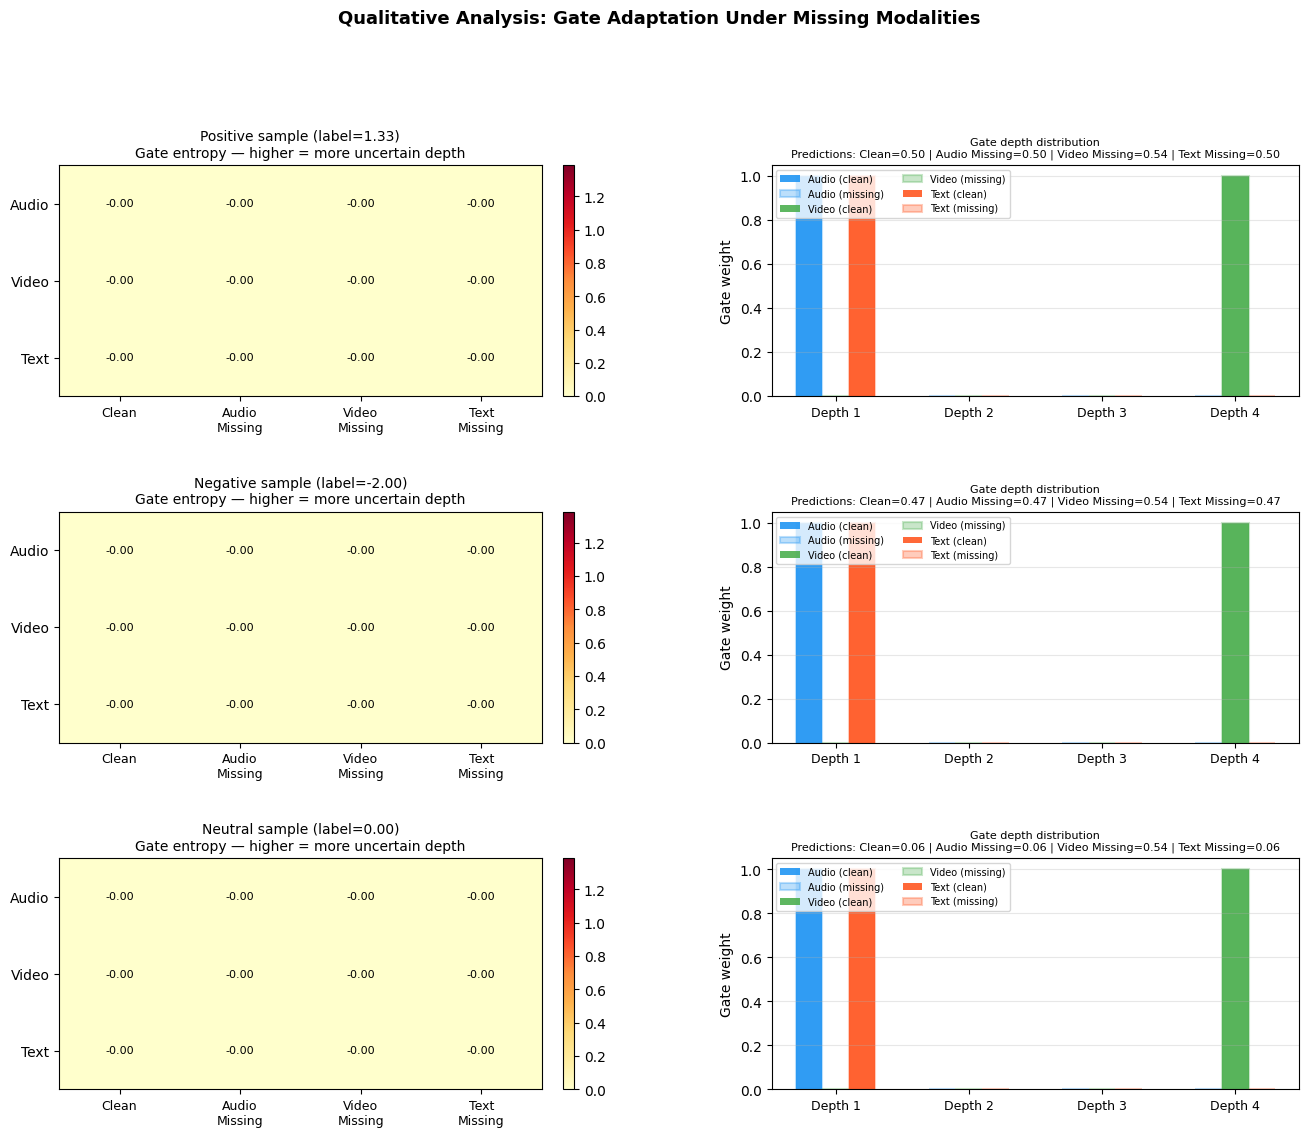

Saved to qualitative_gate_analysis.png

── Prediction Recovery Under Missing Modalities ────────────────────
Sample        Label    Clean   No Audio   No Video    No Text
------------------------------------------------------------
positive       1.33    0.496      0.496      0.535      0.496
negative      -2.00    0.468      0.468      0.536      0.468
neutral        0.00    0.058      0.058      0.536      0.058


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSD_DIR = '/content/drive/MyDrive/CMU_MOSEI/'

adaptive_model.eval()

def get_gates_and_pred(audio, video, text, tau=0.05):
    with torch.no_grad():
        pred, na, nv, nt, gates = adaptive_model(audio, video, text, tau=tau)
    return pred.cpu().numpy(), gates.cpu().numpy()

def get_sample(idx):
    sid, entry = list(aligned['test'].items())[idx]
    audio = torch.from_numpy(
        pad_or_trunc(clean(entry['audio']), MAX_A)).unsqueeze(0).to(device)
    video = torch.from_numpy(
        pad_or_trunc(clean(entry['video']), MAX_V)).unsqueeze(0).to(device)
    text  = torch.from_numpy(
        clean(bert_cache.get(sid, np.zeros(768, dtype=np.float32))).reshape(1, -1)
    ).unsqueeze(0).to(device)
    label = float(entry['label'])
    return audio, video, text, label, sid

# ── Pick samples ──────────────────────────────────────────────────────────────
sample_indices = []
for i, (sid, entry) in enumerate(list(aligned['test'].items())[:2000]):
    label = float(entry['label'])
    if label > 1.0 and not any(s == 'positive' for s, _ in sample_indices):
        sample_indices.append(('positive', i))
    if label < -1.0 and not any(s == 'negative' for s, _ in sample_indices):
        sample_indices.append(('negative', i))
    if abs(label) < 0.1 and not any(s == 'neutral' for s, _ in sample_indices):
        sample_indices.append(('neutral', i))
    if len(sample_indices) == 3:
        break

# Reorder positive, negative, neutral
sample_indices_ordered = []
for target in ['positive', 'negative', 'neutral']:
    for sentiment, idx in sample_indices:
        if sentiment == target:
            sample_indices_ordered.append((sentiment, idx))
            break
sample_indices = sample_indices_ordered

print("Ordered samples:")
for sentiment, idx in sample_indices:
    _, _, _, label, sid = get_sample(idx)
    print(f"  {sentiment}: label={label:.2f}  sid={sid}")

modality_names   = ['Audio', 'Video', 'Text']
condition_labels = ['Clean', 'Audio\nMissing', 'Video\nMissing', 'Text\nMissing']
colors           = ['#2196F3', '#4CAF50', '#FF5722']

fig = plt.figure(figsize=(16, 4 * len(sample_indices)))
gs  = gridspec.GridSpec(len(sample_indices), 2, figure=fig,
                        wspace=0.35, hspace=0.5)

for row, (sentiment, idx) in enumerate(sample_indices):
    audio, video, text, label, sid = get_sample(idx)
    zero_a = torch.zeros_like(audio)
    zero_v = torch.zeros_like(video)
    zero_t = torch.zeros_like(text)

    conditions = [
        ('Clean',         audio,  video,  text),
        ('Audio Missing', zero_a, video,  text),
        ('Video Missing', audio,  zero_v, text),
        ('Text Missing',  audio,  video,  zero_t),
    ]

    all_gates = []
    all_preds = []
    for name, a, v, t in conditions:
        pred, gates = get_gates_and_pred(a, v, t)
        all_gates.append(gates[0])
        all_preds.append(pred[0])

    # ── Left plot: gate entropy heatmap ───────────────────────────────────────
    ax_gates = fig.add_subplot(gs[row, 0])
    gate_matrix  = np.array(all_gates)  # (4, 3, K)
    gate_entropy = -(gate_matrix * np.log(gate_matrix + 1e-8)).sum(axis=-1)  # (4, 3)

    im = ax_gates.imshow(gate_entropy.T, aspect='auto', cmap='YlOrRd',
                         vmin=0, vmax=np.log(K))
    ax_gates.set_xticks(range(4))
    ax_gates.set_xticklabels(condition_labels, fontsize=9)
    ax_gates.set_yticks(range(3))
    ax_gates.set_yticklabels(modality_names, fontsize=10)
    ax_gates.set_title(f'{sentiment.capitalize()} sample (label={label:.2f})\n'
                       f'Gate entropy — higher = more uncertain depth',
                       fontsize=10)
    plt.colorbar(im, ax=ax_gates, fraction=0.046, pad=0.04)

    for ci in range(4):
        for mi in range(3):
            ax_gates.text(ci, mi, f'{gate_entropy[ci, mi]:.2f}',
                         ha='center', va='center', fontsize=8,
                         color='black' if gate_entropy[ci, mi] < 0.7 else 'white')

    # ── Right plot: gate depth distribution ───────────────────────────────────
    ax_depth = fig.add_subplot(gs[row, 1])
    x     = np.arange(K)
    width = 0.2
    for m_idx, (m_name, color) in enumerate(zip(modality_names, colors)):
        clean_weights   = all_gates[0][m_idx]
        missing_weights = all_gates[m_idx + 1][m_idx]
        ax_depth.bar(x + m_idx * width, clean_weights,
                     width, alpha=0.9, color=color,
                     label=f'{m_name} (clean)')
        ax_depth.bar(x + m_idx * width, missing_weights,
                     width, alpha=0.3, color=color,
                     edgecolor=color, linewidth=1.5,
                     label=f'{m_name} (missing)')

    ax_depth.set_xticks(x + width)
    ax_depth.set_xticklabels([f'Depth {k+1}' for k in range(K)], fontsize=9)
    ax_depth.set_ylabel('Gate weight')
    ax_depth.set_ylim(0, 1.05)
    pred_str = ' | '.join([f'{c.replace(chr(10), " ")}={p:.2f}'
                            for c, p in zip(condition_labels, all_preds)])
    ax_depth.set_title(f'Gate depth distribution\nPredictions: {pred_str}',
                       fontsize=8)
    ax_depth.legend(fontsize=7, ncol=2, loc='upper left')
    ax_depth.grid(axis='y', alpha=0.3)

plt.suptitle('Qualitative Analysis: Gate Adaptation Under Missing Modalities',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(CSD_DIR + 'qualitative_gate_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to qualitative_gate_analysis.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Prediction Recovery Under Missing Modalities ────────────────────")
print(f"{'Sample':<12} {'Label':>6} {'Clean':>8} {'No Audio':>10} "
      f"{'No Video':>10} {'No Text':>10}")
print("-" * 60)
for sentiment, idx in sample_indices:
    audio, video, text, label, sid = get_sample(idx)
    zero_a = torch.zeros_like(audio)
    zero_v = torch.zeros_like(video)
    zero_t = torch.zeros_like(text)
    p_clean, _ = get_gates_and_pred(audio,  video,  text)
    p_no_a,  _ = get_gates_and_pred(zero_a, video,  text)
    p_no_v,  _ = get_gates_and_pred(audio,  zero_v, text)
    p_no_t,  _ = get_gates_and_pred(audio,  video,  zero_t)
    print(f"{sentiment:<12} {label:>6.2f} {p_clean[0]:>8.3f} {p_no_a[0]:>10.3f} "
          f"{p_no_v[0]:>10.3f} {p_no_t[0]:>10.3f}")